# 03 — Results Analysis

Reads `results/all_metrics_validated.json` (produced by notebook 02) and generates:

- Heatmaps of all metrics across proteins and comparison categories
- Per-protein RMSD bar charts
- NMR intra-ensemble variability plots
- Category-mean summary table


If `all_metrics_validated.json` is missing, run notebook 02 first.

## Setup

In [1]:
import sys, json, os, re
from pathlib import Path

sys.path.insert(0, "..")  # run from notebooks/ directory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import json as _json_diag

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

json_path = RESULTS_DIR / "all_metrics_validated.json"
assert (
    json_path.exists()
), "all_metrics_validated.json not found — run notebook 02 first."

with open(json_path) as f:
    data = json.load(f)

if isinstance(data, dict) and "comparisons" in data:
    records = data["comparisons"]
elif isinstance(data, list):
    records = data
else:
    raise ValueError("Could not find comparison records in all_metrics_validated.json.")

df = pd.DataFrame(records)

if "status" in df.columns:
    df_all = df.copy()
    df = df[df["status"].fillna("ok").eq("ok")].copy()
else:
    df_all = df.copy()

print("Shape after keeping successful comparisons:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape after keeping successful comparisons: (647, 59)
Columns: ['protein_name', 'uniprot_id', 'comparison', 'category', 'comparison_scope', 'chain_id', 'chain_id_a', 'chain_id_b', 'is_intra_ensemble', 'status', 'rejection_reason', 'notes', 'valid', 'reason', 'warnings', 'n_residues_a', 'n_residues_b', 'n_matched', 'n_mismatches', 'n_gaps', 'coverage_a', 'coverage_b', 'coverage', 'seq_identity', 'x_frac_a', 'x_frac_b', 'method_a', 'pdb_id_a', 'model_idx_a', 'resolution_a', 'n_models_a', 'is_af_a', 'af_version_a', 'plddt_mean_a', 'plddt_confirmed_a', 'plddt_note_a', 'plddt_matched_a', 'method_b', 'pdb_id_b', 'model_idx_b', 'resolution_b', 'n_models_b', 'is_af_b', 'af_version_b', 'plddt_mean_b', 'plddt_confirmed_b', 'plddt_note_b', 'plddt_matched_b', 'organism', 'rmsd', 't_alpha', 't_alpha_n_tri_a', 't_alpha_n_tri_b', 'w_rdist_raw', 'w_rdist_norm', 'b_phipsi', 'b_phipsi_n_a', 'b_phipsi_n_b', 'nmr_flexibility_note']


,protein_name,uniprot_id,comparison,category,comparison_scope,chain_id,chain_id_a,chain_id_b,is_intra_ensemble,status,...,rmsd,t_alpha,t_alpha_n_tri_a,t_alpha_n_tri_b,w_rdist_raw,w_rdist_norm,b_phipsi,b_phipsi_n_a,b_phipsi_n_b,nmr_flexibility_note
0,Barnase,P00648,X-ray_vs_NMR,exp_vs_exp,chain_level,A,A,A,False,ok,...,1.483737,0.040580,1436,1380,0.170423,0.068343,0.017704,106,107,NaN
1,Barnase,P00648,AF2_vs_OF3,af2_vs_of3,chain_level,A,A,A,False,ok,...,18.827715,0.065844,1036,972,9.218342,1.009380,0.150112,155,155,NaN
2,Barnase,P00648,nmr_intra_model0_vs_model1,nmr_intra_ensemble,chain_level,A,A,A,True,ok,...,0.894267,0.024390,1394,1428,0.105725,0.043647,0.002573,108,108,NMR intra-ensemble variability reflects soluti...
3,Barnase,P00648,nmr_intra_model0_vs_model2,nmr_intra_ensemble,chain_level,A,A,A,True,ok,...,1.653777,0.148270,1394,1214,0.177525,0.070970,0.002521,108,108,NMR intra-ensemble variability reflects soluti...
4,Barnase,P00648,nmr_intra_model0_vs_model3,nmr_intra_ensemble,chain_level,A,A,A,True,ok,...,0.876968,0.004323,1394,1388,0.194845,0.077312,0.003471,108,108,NMR intra-ensemble variability reflects soluti...


## Plot helper functions

These helpers make labels short, separate NMR intra-ensemble comparisons from the main plots, and keep annotations readable.

In [2]:
CATEGORY_COLORS = {
    "exp_vs_exp": "tab:blue",
    "exp_vs_af2": "tab:orange",
    "exp_vs_of3": "tab:green",
    "af2_vs_of3": "tab:purple",
    "nmr_intra_ensemble": "tab:gray",
}

CATEGORY_LABELS = {
    "exp_vs_exp": "experimental vs experimental",
    "exp_vs_af2": "experimental vs AF2",
    "exp_vs_of3": "experimental vs OF3",
    "af2_vs_of3": "AF2 vs OF3",
    "nmr_intra_ensemble": "NMR intra-ensemble",
}


def is_nmr_intra(row):
    cat = str(row.get("category", ""))
    comp = str(row.get("comparison", ""))
    flag = row.get("is_intra_ensemble", False)
    return (
        bool(flag)
        or cat == "nmr_intra_ensemble"
        or "nmr_intra" in comp.lower()
        or "model" in comp.lower()
    )


def short_comparison_label(label):
    s = str(label)
    s = s.replace("_vs_", " vs ")
    s = s.replace("Cryo-EM", "Cryo")
    s = s.replace("X-ray", "Xray")
    s = s.replace("AlphaFold2", "AF2").replace("OpenFold3", "OF3")

    m = re.search(r"model(\d+).*model(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"NMR {m.group(1)}–{m.group(2)}"
    return s


def metric_label(metric):
    labels = {
        "rmsd": "RMSD (Å)",
        "b_phipsi": "b-phi/psi (Bhattacharyya distance)",
        "t_alpha": "t-alpha (Å)",
        "w_rdist_raw": "w-rdist raw (Å)",
        "w_rdist_norm": "w-rdist normalised (dimensionless)",
    }
    return labels.get(metric, metric)


def fmt_for_metric(metric):
    if metric in {"t_alpha", "w_rdist_norm", "b_phipsi"}:
        return ".3f"
    return ".2f"


def save_show(fig, filename):
    out = RESULTS_DIR / filename
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


df = df.copy()
df["is_nmr_intra_plot"] = df.apply(is_nmr_intra, axis=1)
main_df = df[~df["is_nmr_intra_plot"]].copy()
nmr_df = df[df["is_nmr_intra_plot"]].copy()

print(f"Main comparison rows: {len(main_df)}")
print(f"NMR intra-ensemble rows: {len(nmr_df)}")

_MIN_EXPECTED_ROWS = 1  # minimum sane number of comparisons; scales with dataset
if len(main_df) < _MIN_EXPECTED_ROWS:
    print()
    print("=" * 70)
    print(
        f"WARNING: main_df has only {len(main_df)} rows — pipeline output looks empty."
    )
    print("Your all_metrics_validated.json is likely incomplete.")
    print(
        "FIX: re-run notebooks 00 → 01 → 02 to regenerate the JSON, then re-run this notebook."
    )
    print()
    print("Records currently in main_df:")
    for _, _r in main_df.iterrows():
        print(f"  {_r.get('protein_name','?'):15s} | {_r.get('comparison','?')}")
    print("=" * 70)
    print()

Main comparison rows: 173
NMR intra-ensemble rows: 474


In [3]:
_raw = _json_diag.load(open(json_path))
_all_records = _raw if isinstance(_raw, list) else _raw.get("comparisons", [])
print(f"Total records in JSON: {len(_all_records)}")

_main_cats = ("exp_vs_exp", "exp_vs_af2", "exp_vs_of3", "af2_vs_of3")
_main = [
    r
    for r in _all_records
    if r.get("category") in _main_cats and r.get("status") == "ok"
]
_rejected = [r for r in _all_records if r.get("status") != "ok"]
print(f"Main comparison records (status=ok): {len(_main)}")
print(f"Rejected/error records: {len(_rejected)}")

print()
print("Main records breakdown:")
for r in _main:
    flag = r.get("is_intra_ensemble", "???")
    rmsd = r.get("rmsd", "MISSING")
    print(
        f"  {r['protein_name']:15s} | {r['comparison']:30s} | is_intra={flag!r:8s} | rmsd={rmsd}"
    )

print()
if _rejected:
    print("Rejection reasons:")
    for r in _rejected[:10]:  # show first 10
        print(
            f"  {r.get('protein_name','?'):15s} | {r.get('comparison','?'):30s} | {r.get('status','?')} | {str(r.get('rejection_reason',''))[:120]}"
        )
    if len(_rejected) > 10:
        print(f"  ... and {len(_rejected)-10} more")

print()
print(f"main_df rows after is_nmr_intra filter: {len(main_df)}")
print(f"nmr_df rows: {len(nmr_df)}")
if len(main_df) < len(_main):
    print()
    print("WARNING: some records classified as nmr_intra unexpectedly!")
    print("Rows in _main but not in main_df:")
    main_comps = set(zip(main_df["protein_name"], main_df["comparison"]))
    for r in _main:
        if (r["protein_name"], r["comparison"]) not in main_comps:
            flag = r.get("is_intra_ensemble")
            cat = r.get("category")
            comp = r.get("comparison", "")
            print(
                f"  {r['protein_name']} | {comp} | is_intra={flag!r} | category={cat}"
            )
            print(f"    'nmr_intra' in comp: {'nmr_intra' in comp.lower()}")
            print(f"    'model' in comp:     {'model' in comp.lower()}")
# ─────────────────────────────────────────────────────────────────────────────

Total records in JSON: 647
Main comparison records (status=ok): 173
Rejected/error records: 0

Main records breakdown:
  Barnase         | X-ray_vs_NMR                   | is_intra=False    | rmsd=1.483737
  Barnase         | AF2_vs_OF3                     | is_intra=False    | rmsd=18.827715
  Protein G (GB1 domain parent) | AF2_vs_OF3                     | is_intra=False    | rmsd=65.414104
  Adenylate kinase (E. coli) | X-ray_vs_AF2                   | is_intra=False    | rmsd=0.685501
  Adenylate kinase (E. coli) | X-ray_vs_OF3                   | is_intra=False    | rmsd=19.692673
  Adenylate kinase (E. coli) | AF2_vs_OF3                     | is_intra=False    | rmsd=19.585764
  T4 lysozyme     | NMR_vs_OF3                     | is_intra=False    | rmsd=14.540902
  Myoglobin       | X-ray_vs_NMR                   | is_intra=False    | rmsd=1.604318
  Myoglobin       | X-ray_vs_AF2                   | is_intra=False    | rmsd=0.434244
  Myoglobin       | NMR_vs_AF2                

## Summary table

In [4]:
display_cols = [
    "protein_name",
    "comparison",
    "category",
    "rmsd",
    "b_phipsi",
    "t_alpha",
    "w_rdist_raw",
    "w_rdist_norm",
    "n_matched",
    "coverage",
    "seq_identity",
]
display_cols = [c for c in display_cols if c in df.columns]
summary_table = df[display_cols].sort_values(["protein_name", "category", "comparison"])
summary_table.to_csv(RESULTS_DIR / "summary_table_readable.csv", index=False)
summary_table

,protein_name,comparison,category,rmsd,b_phipsi,t_alpha,w_rdist_raw,w_rdist_norm,n_matched,coverage,seq_identity
646,ATP synthase subunit beta,AF2_vs_OF3,af2_vs_of3,26.009605,0.044164,0.255088,3.427145,0.646124,528,1.0,1.0
643,ATP synthase subunit beta,Cryo-EM_vs_AF2,exp_vs_af2,2.459074,0.005528,0.122739,0.084909,0.035393,469,1.0,1.0
642,ATP synthase subunit beta,X-ray_vs_AF2,exp_vs_af2,2.981604,0.002689,0.070866,0.122369,0.050136,467,1.0,1.0
641,ATP synthase subunit beta,X-ray_vs_Cryo-EM,exp_vs_exp,0.750696,0.001704,0.056373,0.091057,0.037847,467,1.0,1.0
645,ATP synthase subunit beta,Cryo-EM_vs_OF3,exp_vs_of3,25.054238,0.023350,0.051784,1.987720,0.475340,469,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
635,V-ATPase subunit A,Cryo-EM_vs_AF2,exp_vs_af2,1.262005,0.008761,0.037904,0.841554,0.265184,600,1.0,1.0
636,V-ATPase subunit A,Cryo-EM_vs_OF3,exp_vs_of3,28.189863,0.027090,0.004315,2.446424,0.537369,600,1.0,1.0
579,Vimentin,AF2_vs_OF3,af2_vs_of3,52.916138,0.033631,0.148855,20.180922,1.325945,466,1.0,1.0
500,c-Myc,AF2_vs_OF3,af2_vs_of3,48.842415,0.041404,0.241211,20.855440,1.339560,454,1.0,1.0


In [5]:
# Confirm expected display columns are present
assert all(
    c in df.columns for c in ["protein_name", "comparison"]
), "Unexpected column schema — re-run notebook 02 to regenerate results."

## Metric correlation — main comparisons only

Saved: ../results/metric_correlation.png


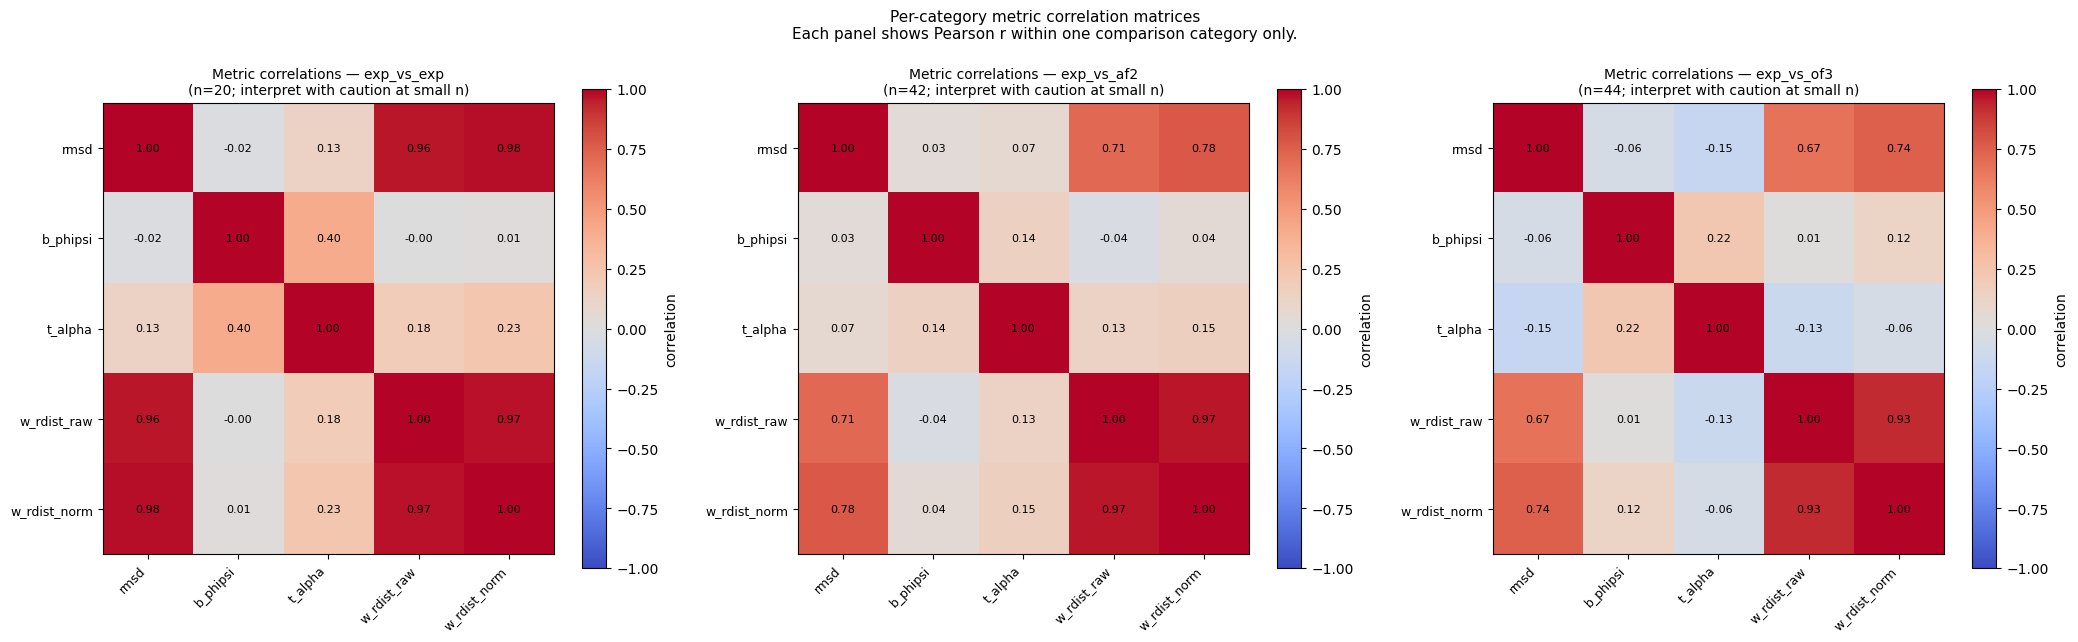

In [6]:
metric_cols = [
    c
    for c in [
        "rmsd",
        "b_phipsi",
        "t_alpha",
        "w_rdist_raw",
        "w_rdist_norm",
    ]
    if c in main_df.columns
]

MIN_CORR_OBS = 4
CATEGORIES_TO_CORRELATE = ["exp_vs_exp", "exp_vs_af2", "exp_vs_of3"]

available_cats = [c for c in CATEGORIES_TO_CORRELATE if c in main_df["category"].values]

if not available_cats:
    print("No relevant categories found in main_df. Correlation matrix skipped.")
else:
    n_cats = len(available_cats)
    fig, axes = plt.subplots(1, n_cats, figsize=(7 * n_cats, 6), squeeze=False)

    for ax, cat in zip(axes[0], available_cats):
        cat_data = main_df[main_df["category"] == cat][metric_cols].dropna()
        n_obs = len(cat_data)

        if n_obs < MIN_CORR_OBS:
            ax.text(
                0.5,
                0.5,
                f"Skipped ({cat})\nOnly {n_obs} complete rows.\n"
                f"Need at least {MIN_CORR_OBS}.",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
            )
            ax.set_title(cat, fontsize=10)
            continue

        corr = cat_data.corr()

        im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr.columns)))
        ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
        ax.set_yticks(range(len(corr.index)))
        ax.set_yticklabels(corr.index, fontsize=9)

        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                ax.text(
                    j,
                    i,
                    f"{corr.values[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

        plt.colorbar(im, ax=ax, label="correlation")

        caution = ""
        if "protein_name" in main_df.columns:
            counts = main_df.loc[cat_data.index, "protein_name"].value_counts()
            dominant = counts[counts / n_obs > 0.5]
            if not dominant.empty:
                names = ", ".join(dominant.index.tolist())
                caution = f"\nmay be driven by: {names}"

        ax.set_title(
            f"Metric correlations — {cat}\n"
            f"(n={n_obs}{caution}; interpret with caution at small n)",
            fontsize=10,
        )

    plt.suptitle(
        "Per-category metric correlation matrices\n"
        "Each panel shows Pearson r within one comparison category only.",
        fontsize=11,
        y=1.02,
    )
    plt.tight_layout()
    save_show(fig, "metric_correlation.png")

## Readable heatmaps — main comparisons only

NMR intra-ensemble rows are intentionally excluded here. They are plotted separately below.

Saved: ../results/heatmap_rmsd.png


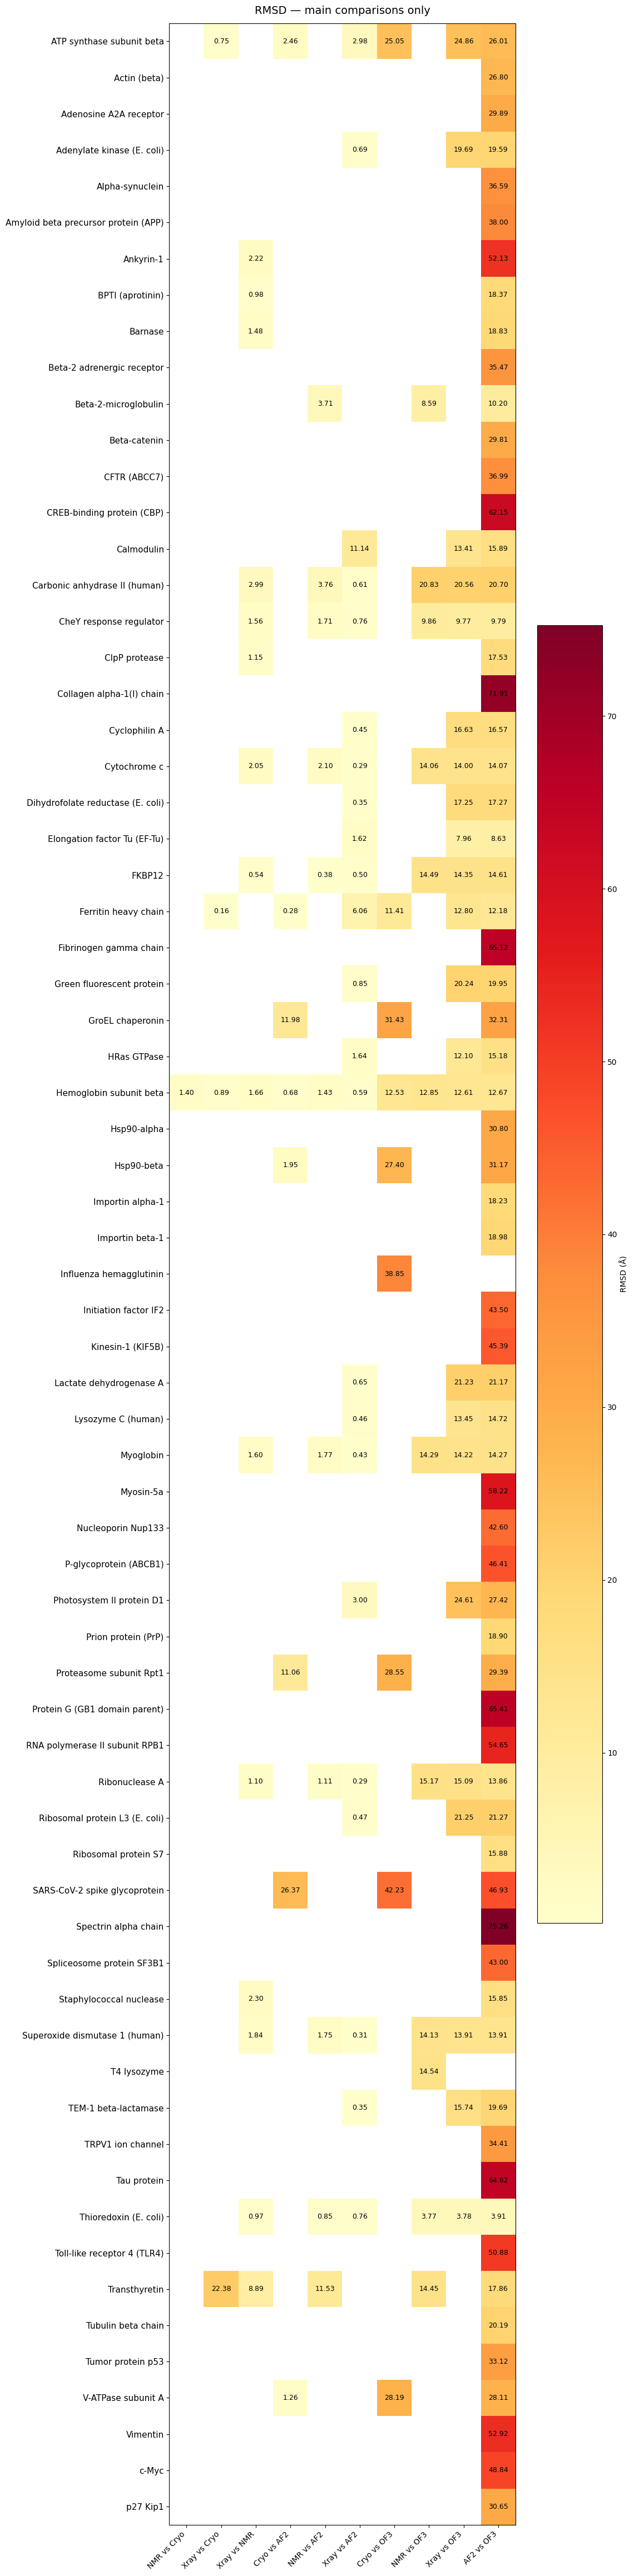

Saved: ../results/heatmap_t_alpha.png


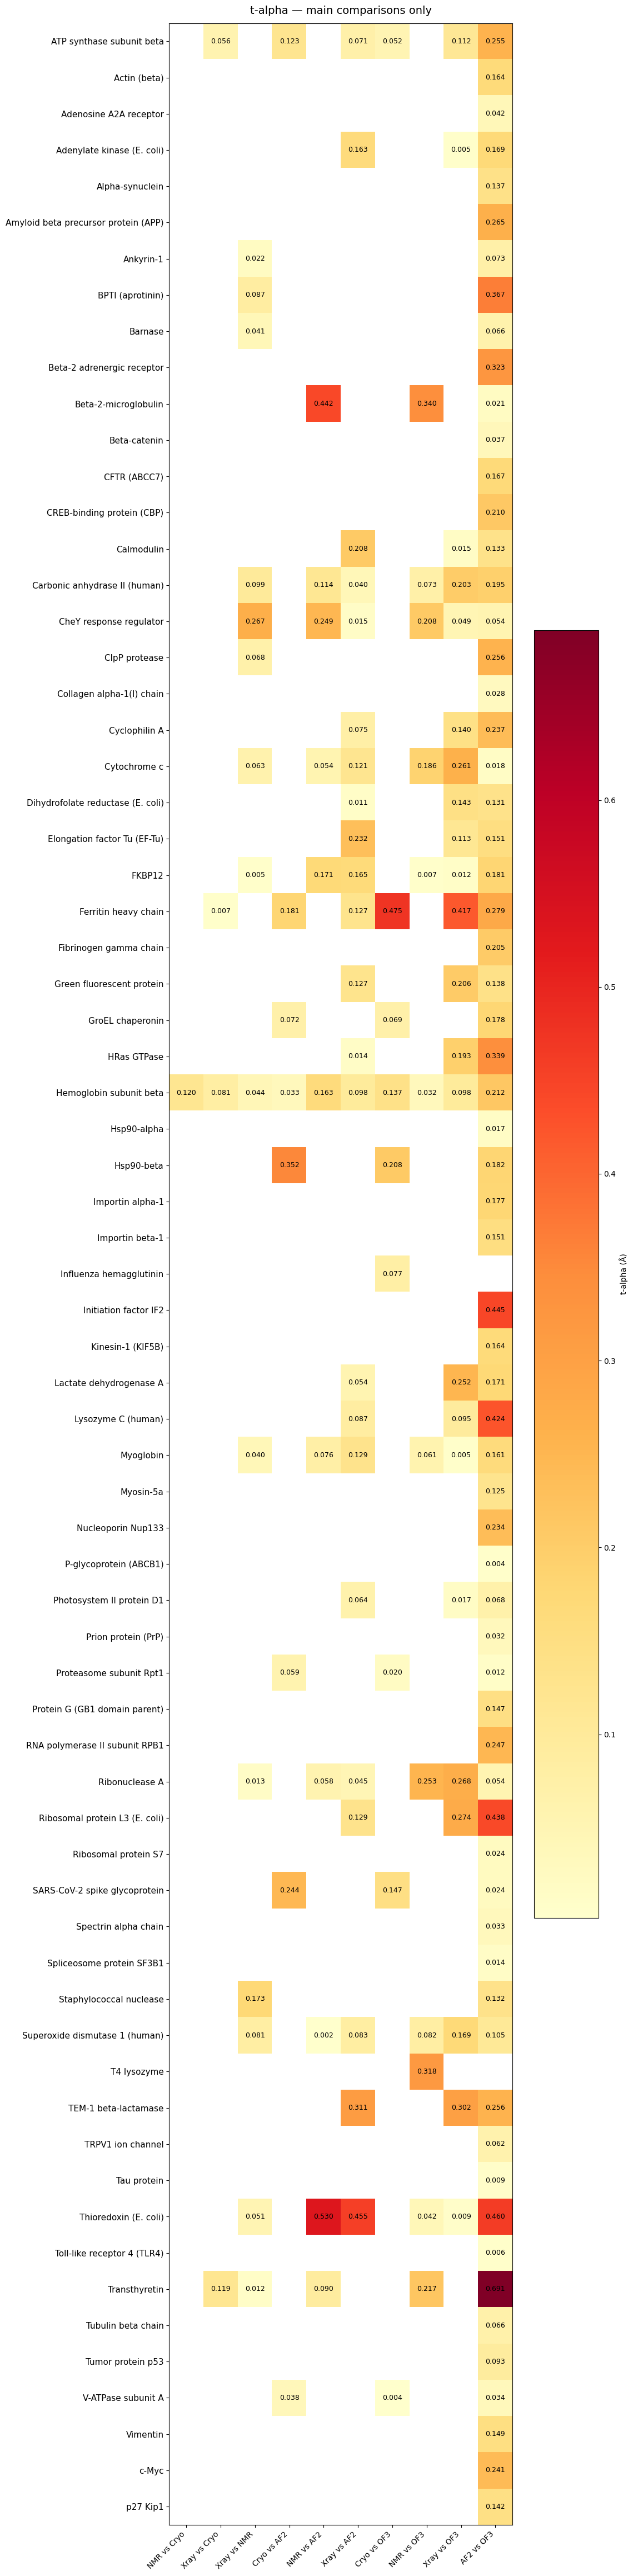

Saved: ../results/heatmap_b_phipsi.png


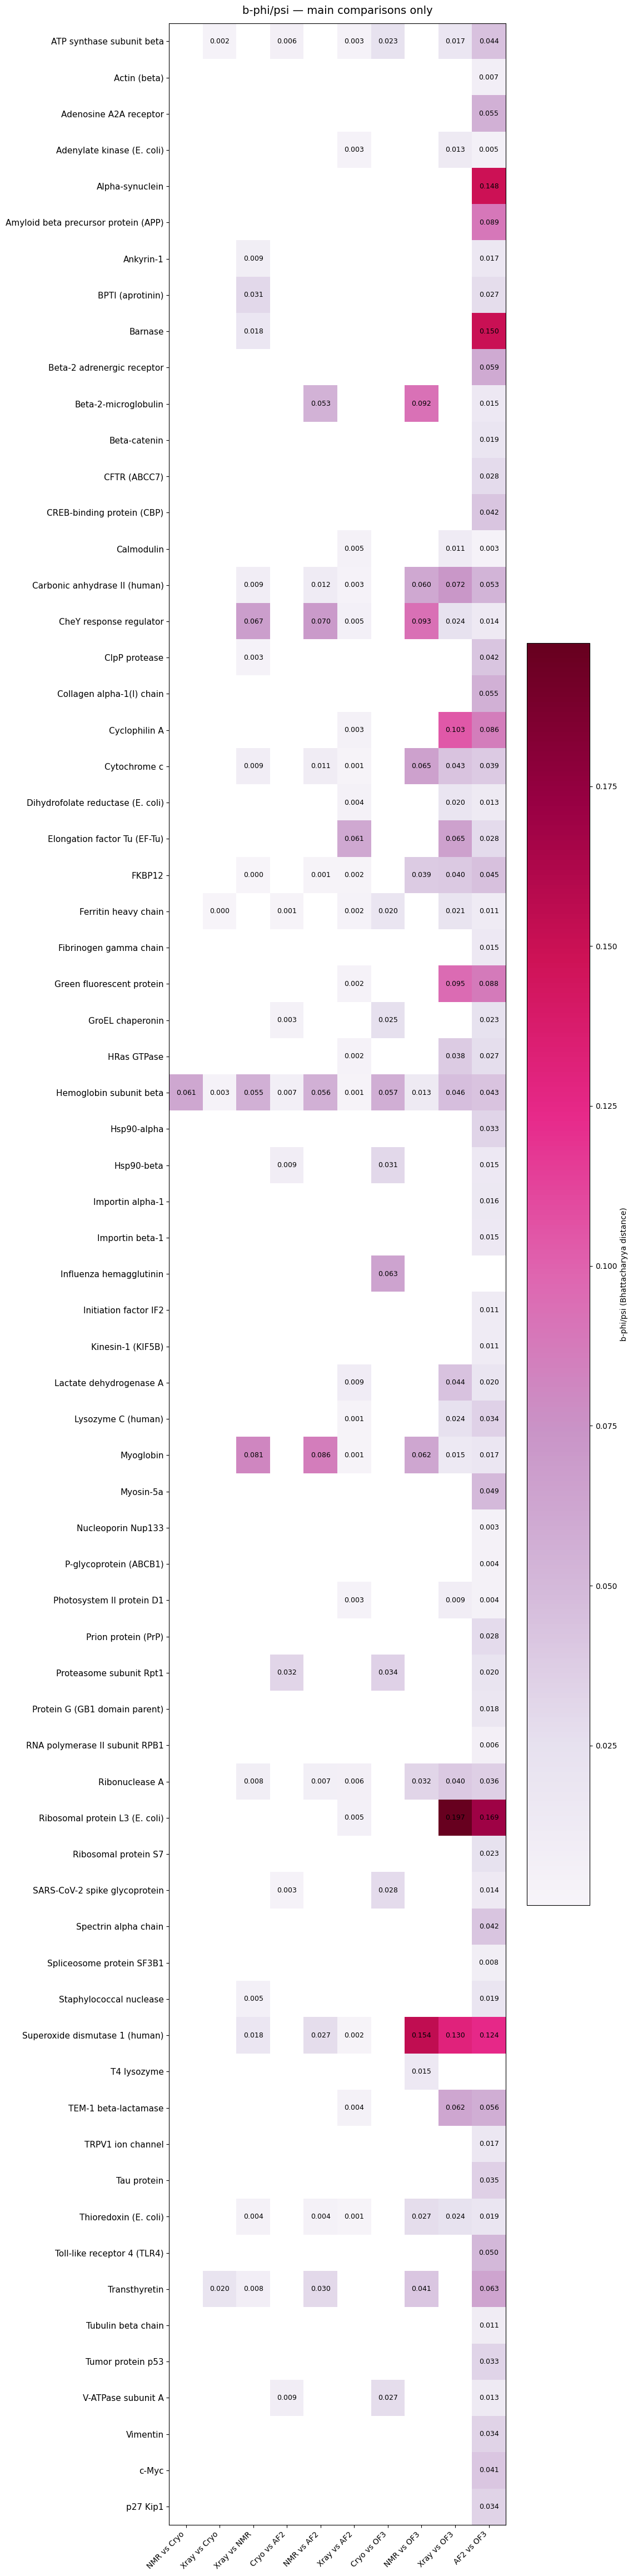

In [7]:
def readable_heatmap(metric, title=None, cmap="YlOrRd", filename=None):
    if metric not in main_df.columns:
        print(f"Skipping {metric}: not found")
        return

    plot = main_df.dropna(subset=[metric]).copy()
    if plot.empty:
        print(f"Skipping {metric}: no values")
        return

    pivot = plot.pivot_table(
        index="protein_name",
        columns="comparison",
        values=metric,
        aggfunc="mean",
    )

    if "category" in plot.columns:
        order_df = (
            plot[["comparison", "category"]]
            .drop_duplicates()
            .assign(
                cat_order=lambda x: x["category"]
                .map(
                    {"exp_vs_exp": 0, "exp_vs_af2": 1, "exp_vs_of3": 2, "af2_vs_of3": 3}
                )
                .fillna(9)
            )
            .sort_values(["cat_order", "comparison"])
        )
        ordered_cols = [c for c in order_df["comparison"] if c in pivot.columns]
        pivot = pivot[ordered_cols]

    short_cols = [short_comparison_label(c) for c in pivot.columns]

    width = max(8, 1.15 * len(short_cols))
    height = max(3.8, 0.65 * len(pivot.index) + 1.6)
    fig, ax = plt.subplots(figsize=(width, height))

    masked = np.ma.masked_invalid(pivot.values.astype(float))
    im = ax.imshow(masked, cmap=cmap, aspect="auto")

    ax.set_xticks(range(len(short_cols)))
    ax.set_xticklabels(short_cols, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=11)

    fmt = fmt_for_metric(metric)
    for i in range(len(pivot.index)):
        for j in range(len(short_cols)):
            v = pivot.values[i, j]
            if pd.notna(v):
                ax.text(
                    j, i, format(float(v), fmt), ha="center", va="center", fontsize=9
                )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(metric_label(metric))

    ax.set_title(title or metric_label(metric), fontsize=14, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # For the RMSD heatmap, annotate the Calmodulin X-ray vs NMR outlier
    if metric == "rmsd" and "protein_name" in plot.columns:
        cal_idx = (
            list(pivot.index).index("Calmodulin")
            if "Calmodulin" in list(pivot.index)
            else None
        )
        nmr_col_key = next(
            (c for c in pivot.columns if "nmr" in c.lower() and "xray" in c.lower()),
            None,
        )
        if cal_idx is not None and nmr_col_key is not None:
            nmr_col_j = list(pivot.columns).index(nmr_col_key)
            ax.text(
                nmr_col_j,
                cal_idx - 0.38,
                "* Ca²⁺-state difference — see Known Limitations",
                ha="center",
                va="center",
                fontsize=6.5,
                color="white",
                style="italic",
            )

    plt.tight_layout()

    save_show(fig, filename or f"heatmap_{metric}.png")


readable_heatmap(
    "rmsd", "RMSD — main comparisons only", cmap="YlOrRd", filename="heatmap_rmsd.png"
)
readable_heatmap(
    "t_alpha",
    "t-alpha — main comparisons only",
    cmap="YlOrRd",
    filename="heatmap_t_alpha.png",
)
readable_heatmap(
    "b_phipsi",
    "b-phi/psi — main comparisons only",
    cmap="PuRd",
    filename="heatmap_b_phipsi.png",
)

## Per-protein RMSD plots — readable horizontal bars

This replaces the crowded all-protein grouped barplot.

Saved: ../results/rmsd_ATP_synthase_subunit_beta.png


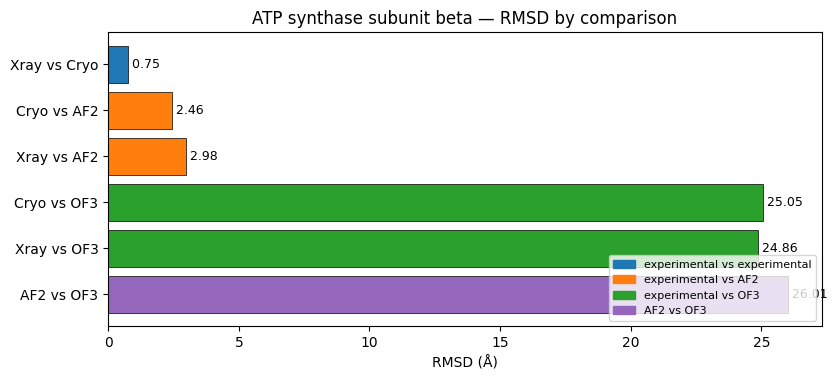

Saved: ../results/rmsd_Actin_beta.png


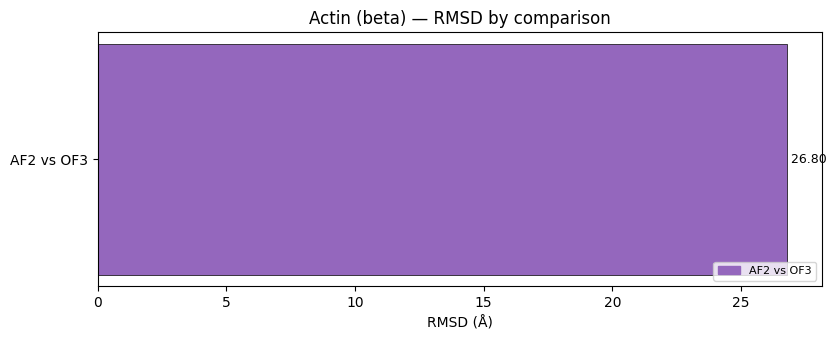

Saved: ../results/rmsd_Adenosine_A2A_receptor.png


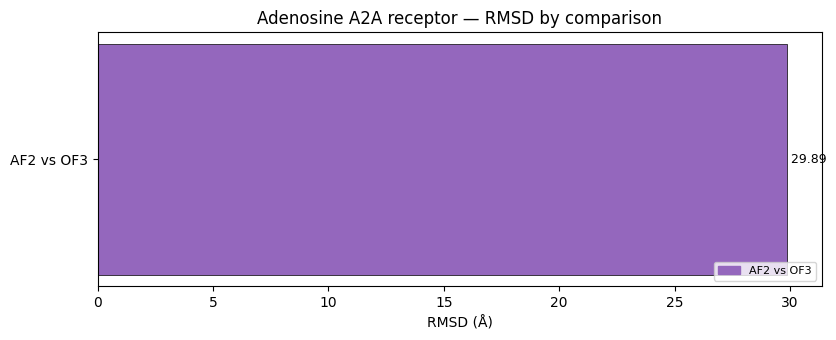

Saved: ../results/rmsd_Adenylate_kinase_E_coli.png


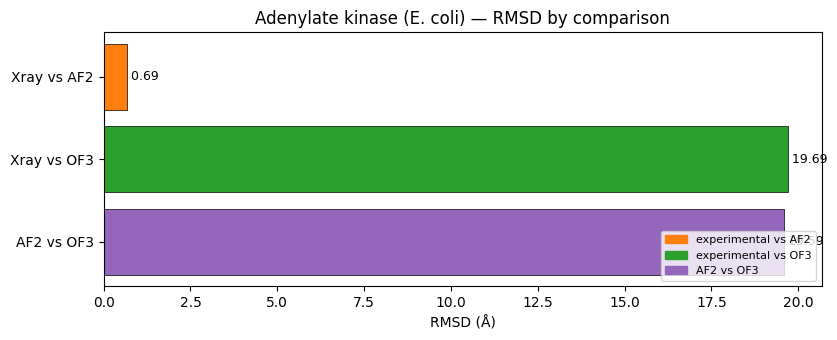

Saved: ../results/rmsd_Alpha-synuclein.png


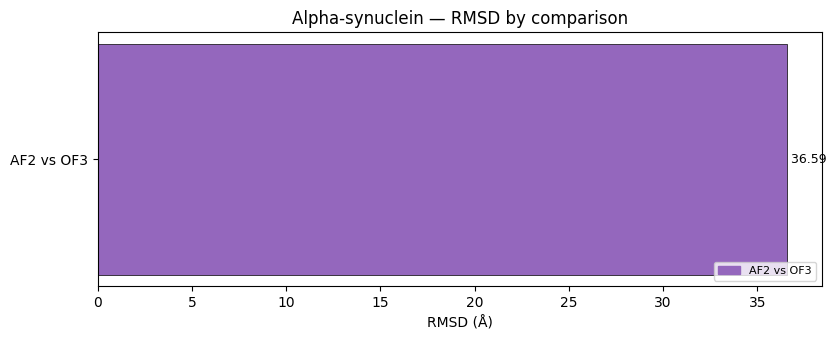

Saved: ../results/rmsd_Amyloid_beta_precursor_protein_APP.png


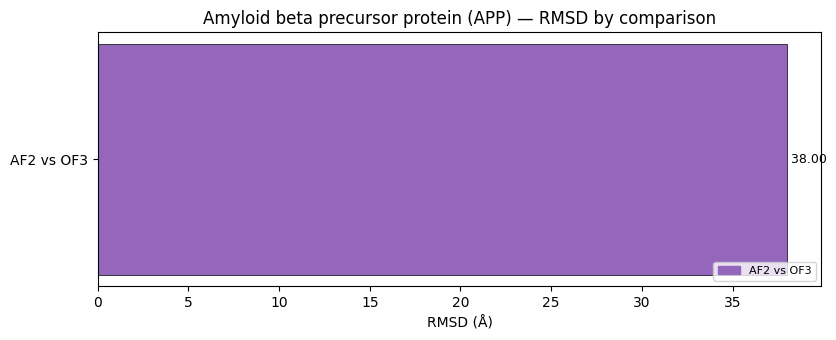

Saved: ../results/rmsd_Ankyrin-1.png


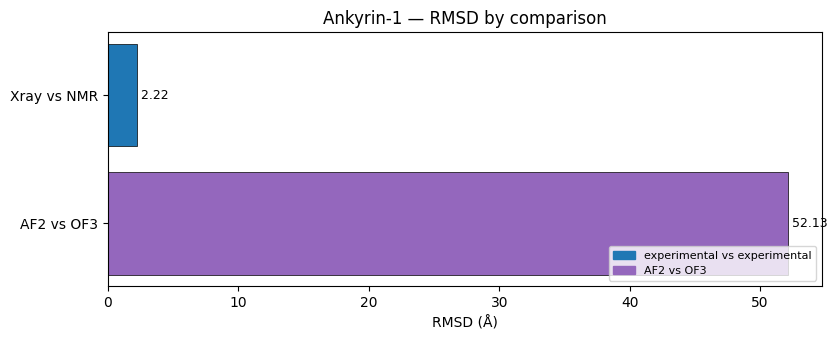

Saved: ../results/rmsd_BPTI_aprotinin.png


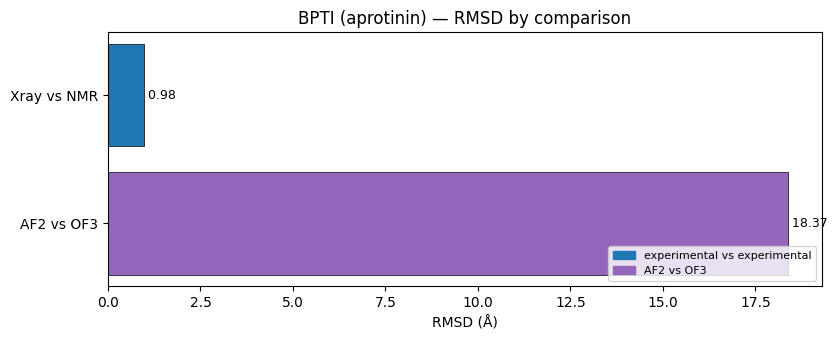

Saved: ../results/rmsd_Barnase.png


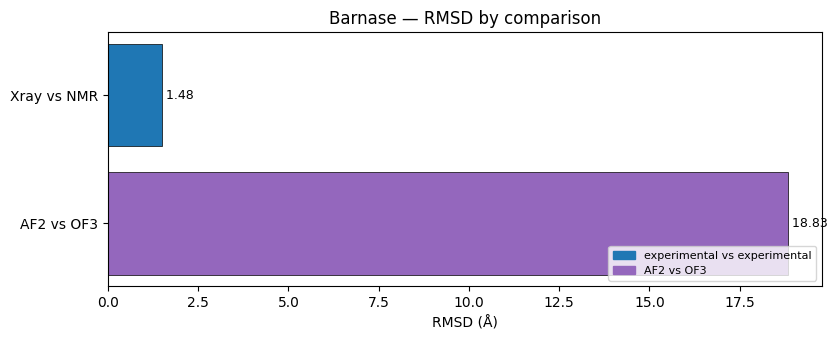

Saved: ../results/rmsd_Beta-2_adrenergic_receptor.png


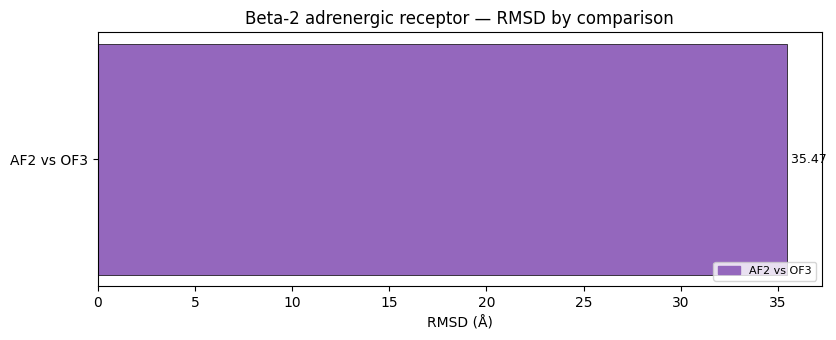

Saved: ../results/rmsd_Beta-2-microglobulin.png


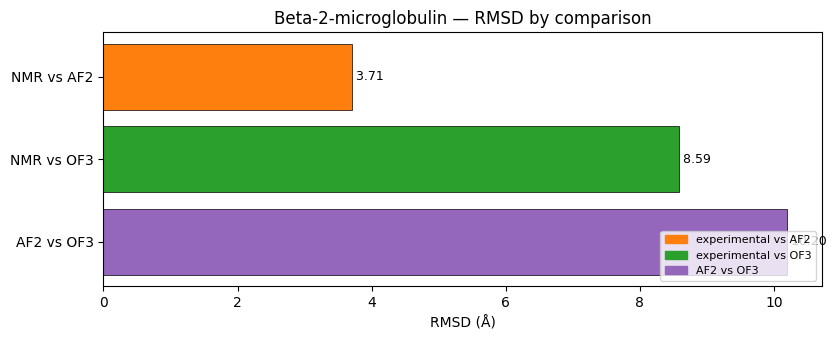

Saved: ../results/rmsd_Beta-catenin.png


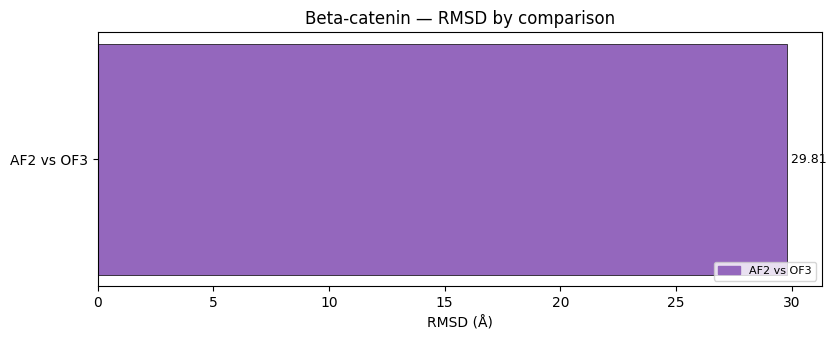

Saved: ../results/rmsd_CFTR_ABCC7.png


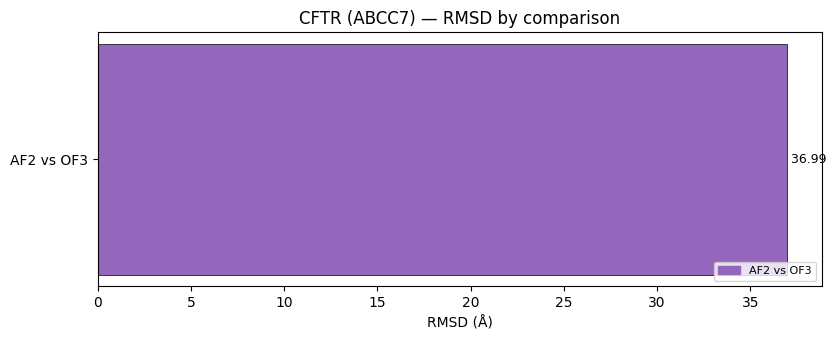

Saved: ../results/rmsd_CREB-binding_protein_CBP.png


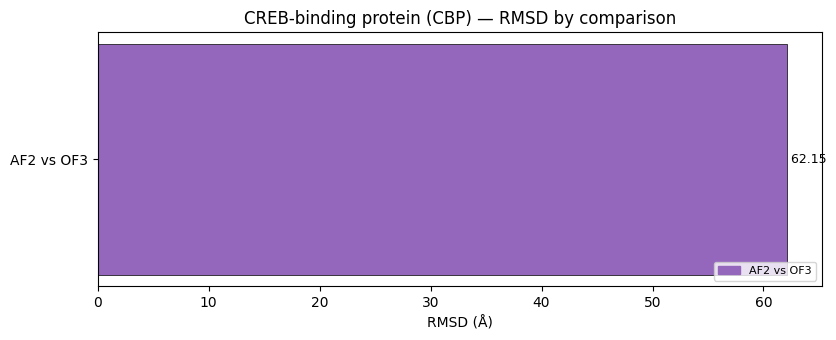

Saved: ../results/rmsd_Calmodulin.png


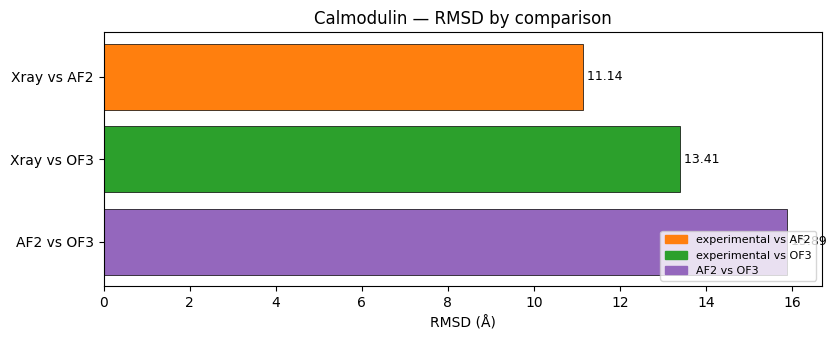

Saved: ../results/rmsd_Carbonic_anhydrase_II_human.png


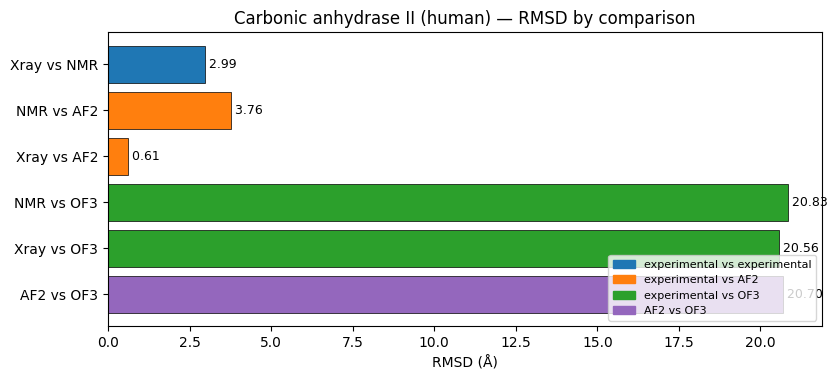

Saved: ../results/rmsd_CheY_response_regulator.png


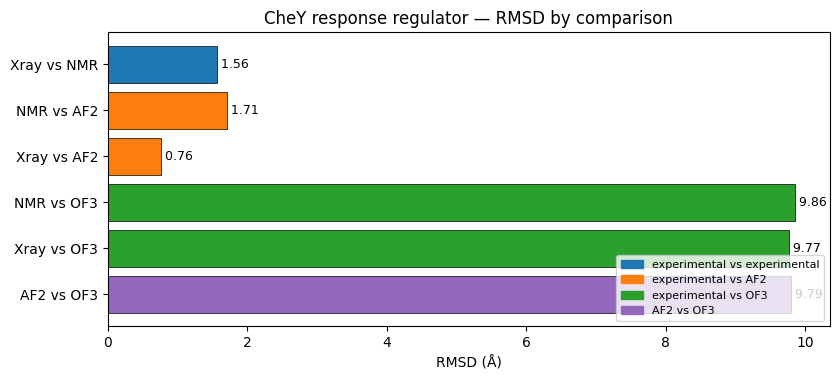

Saved: ../results/rmsd_ClpP_protease.png


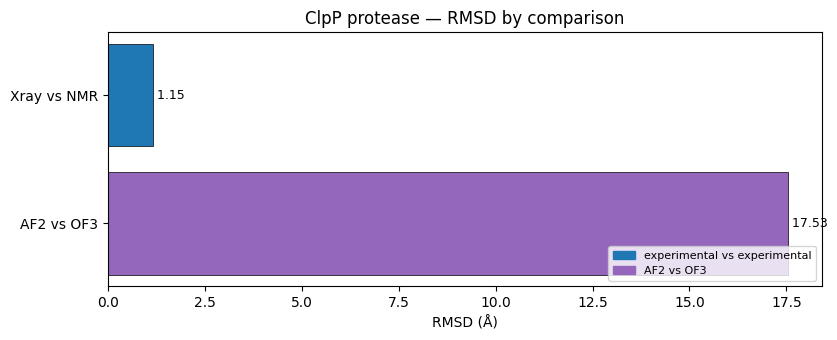

Saved: ../results/rmsd_Collagen_alpha-1_I_chain.png


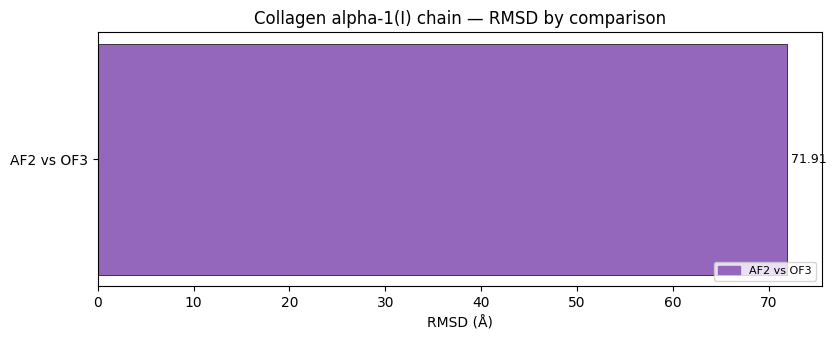

Saved: ../results/rmsd_Cyclophilin_A.png


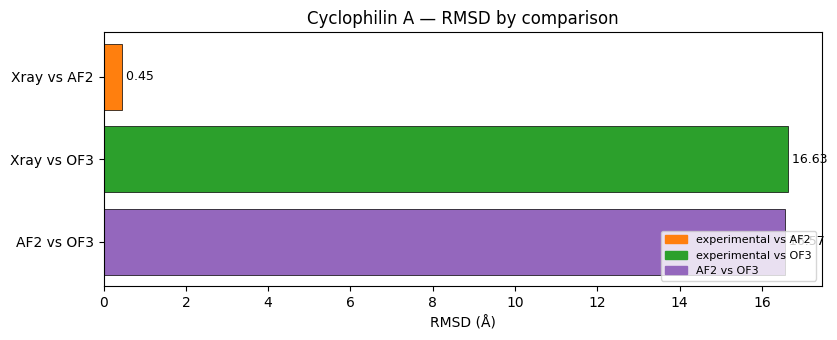

Saved: ../results/rmsd_Cytochrome_c.png


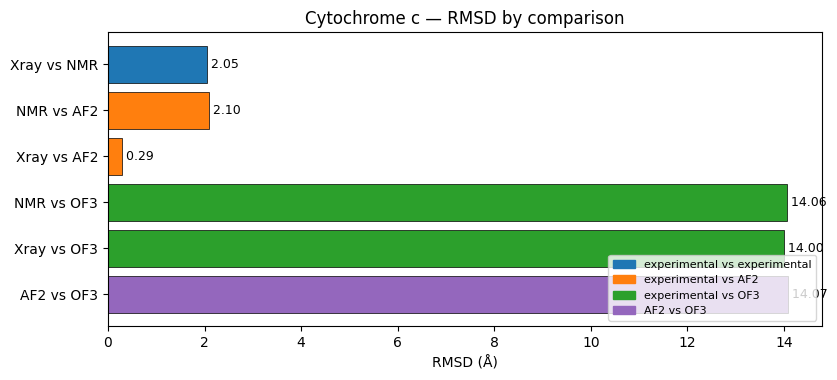

Saved: ../results/rmsd_Dihydrofolate_reductase_E_coli.png


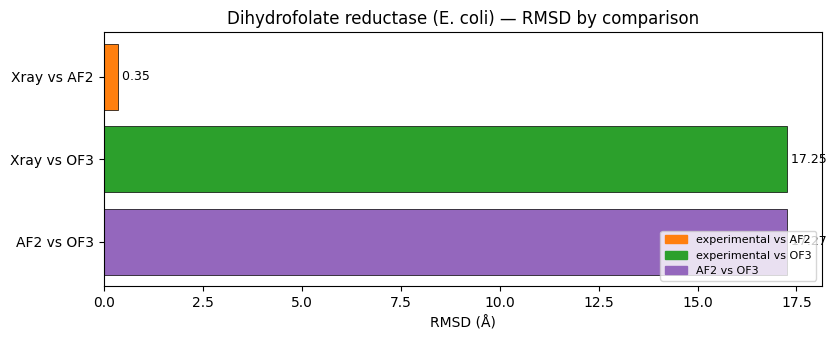

Saved: ../results/rmsd_Elongation_factor_Tu_EF-Tu.png


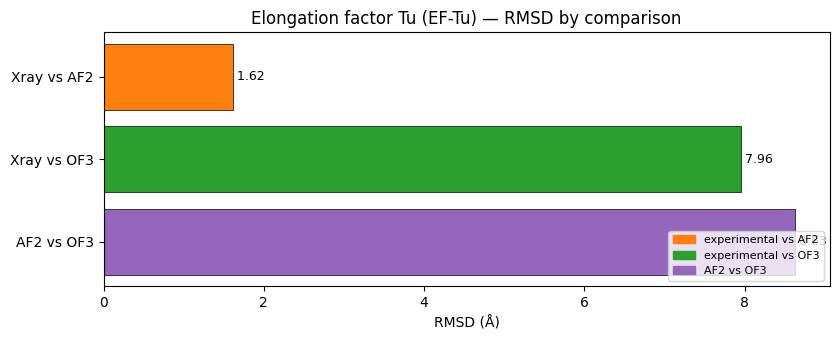

Saved: ../results/rmsd_FKBP12.png


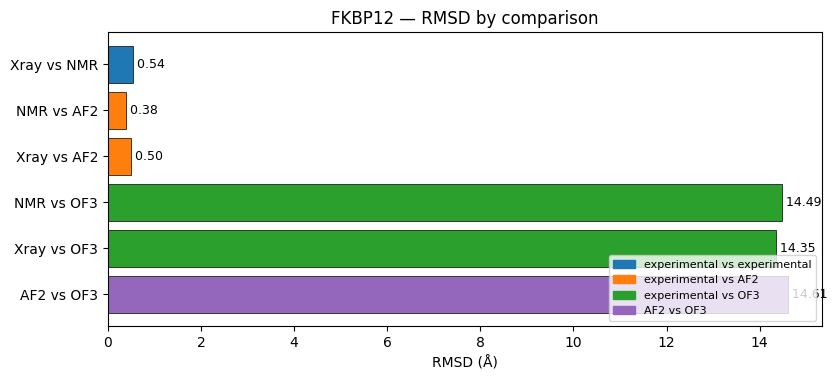

Saved: ../results/rmsd_Ferritin_heavy_chain.png


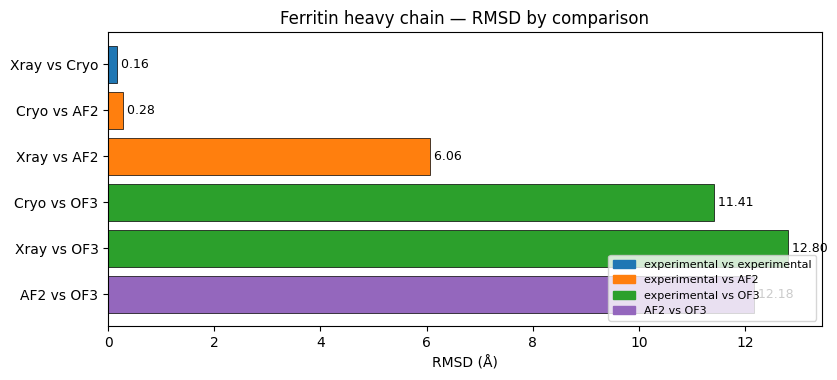

Saved: ../results/rmsd_Fibrinogen_gamma_chain.png


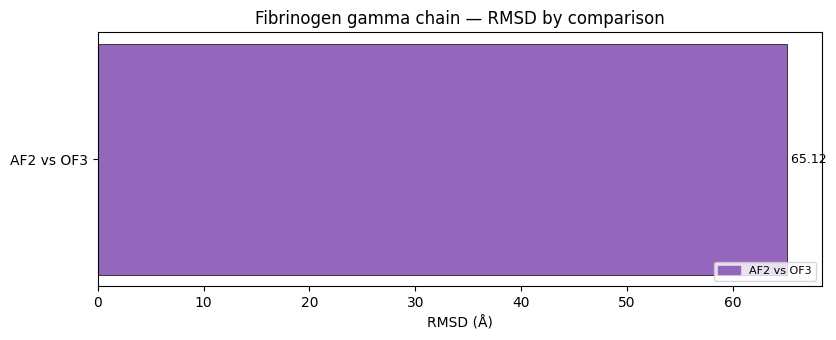

Saved: ../results/rmsd_Green_fluorescent_protein.png


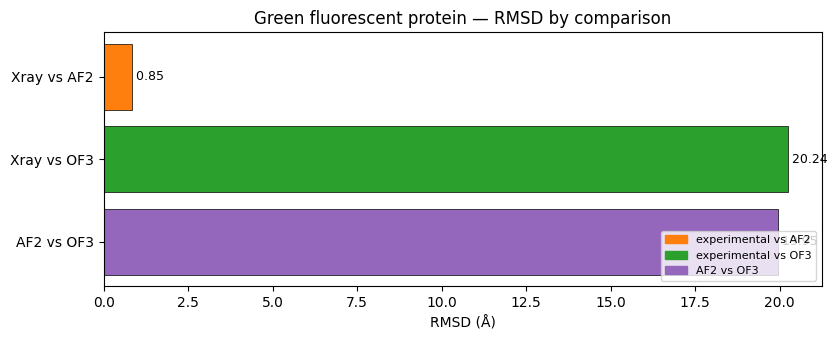

Saved: ../results/rmsd_GroEL_chaperonin.png


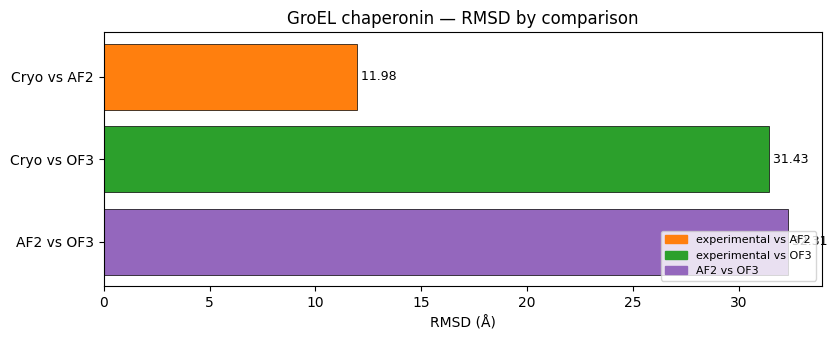

Saved: ../results/rmsd_HRas_GTPase.png


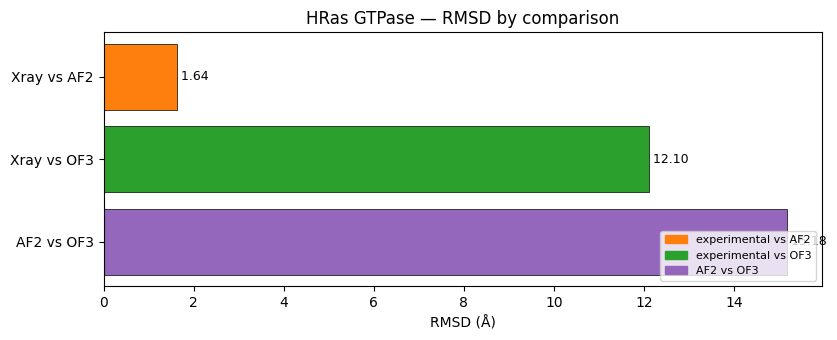

Saved: ../results/rmsd_Hemoglobin_subunit_beta.png


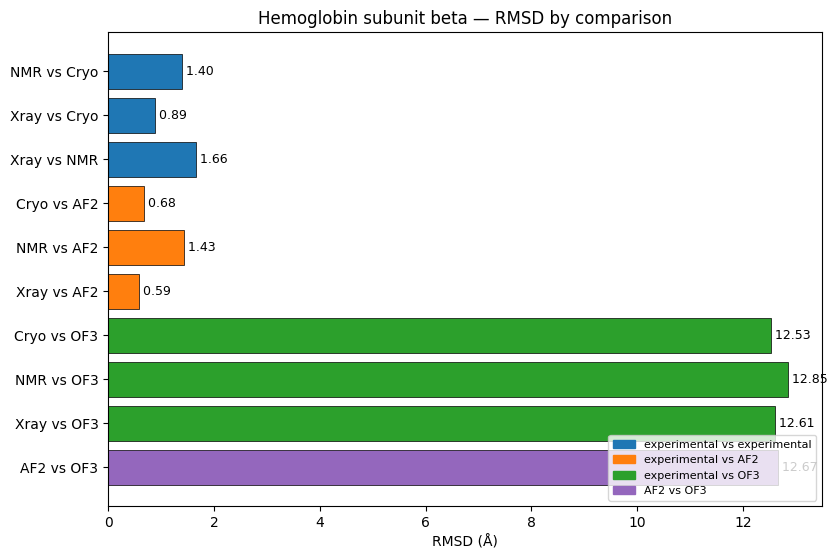

Saved: ../results/rmsd_Hsp90-alpha.png


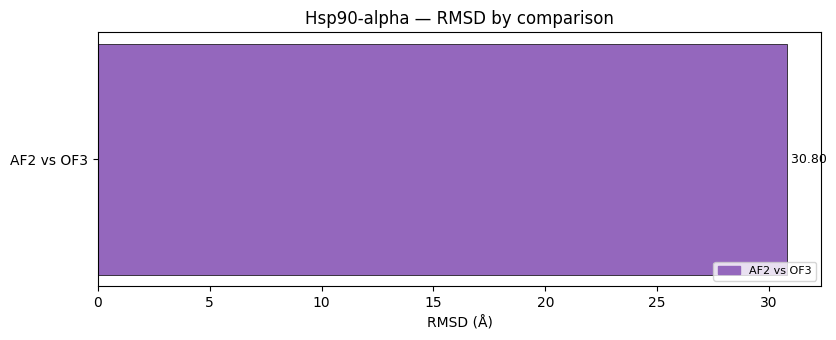

Saved: ../results/rmsd_Hsp90-beta.png


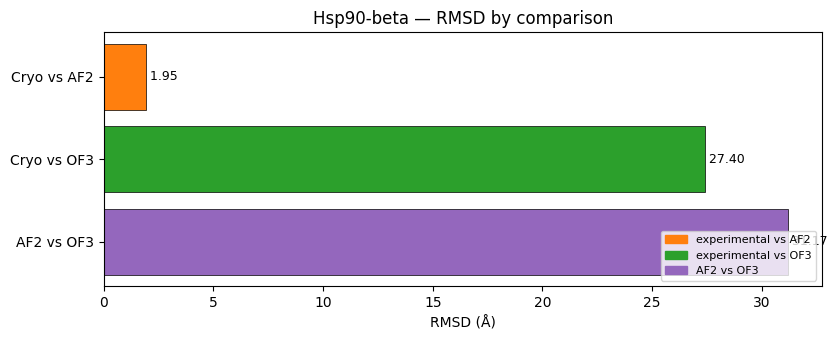

Saved: ../results/rmsd_Importin_alpha-1.png


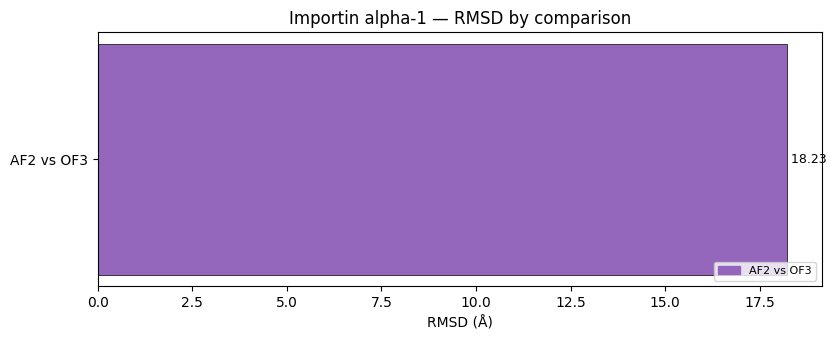

Saved: ../results/rmsd_Importin_beta-1.png


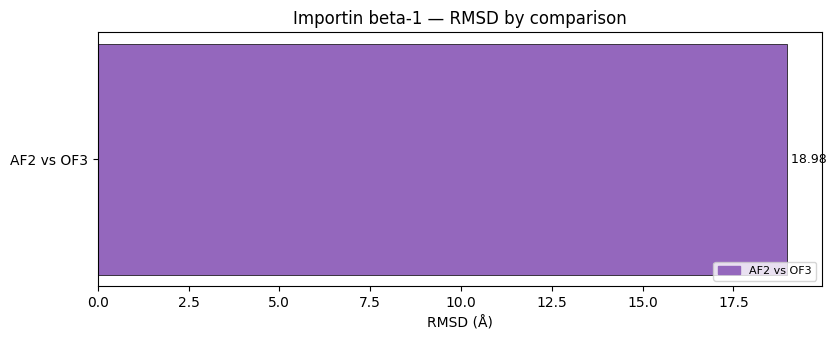

Saved: ../results/rmsd_Influenza_hemagglutinin.png


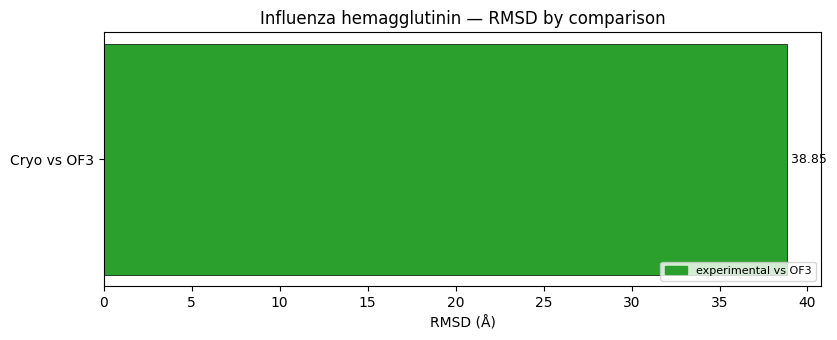

Saved: ../results/rmsd_Initiation_factor_IF2.png


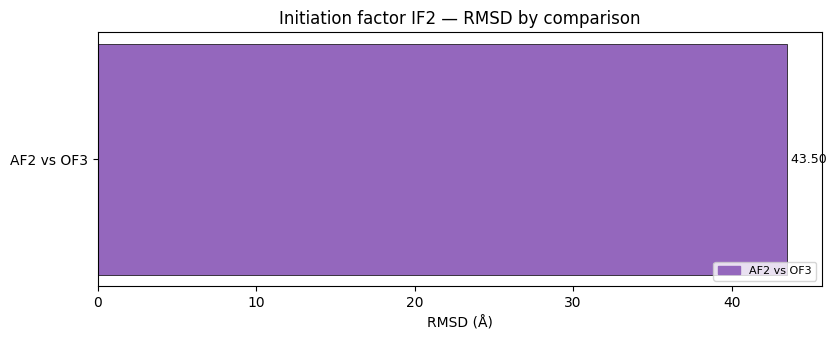

Saved: ../results/rmsd_Kinesin-1_KIF5B.png


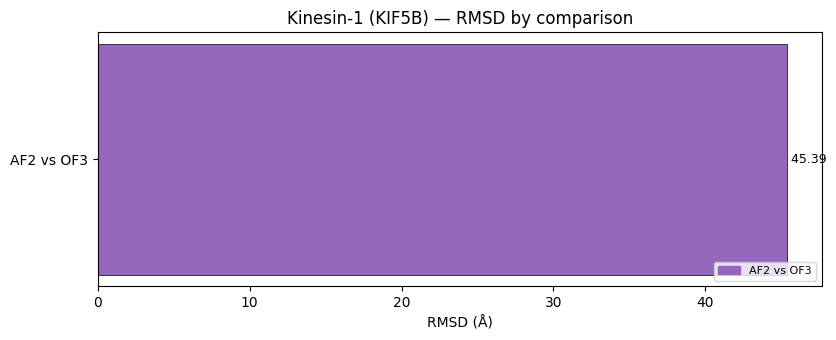

Saved: ../results/rmsd_Lactate_dehydrogenase_A.png


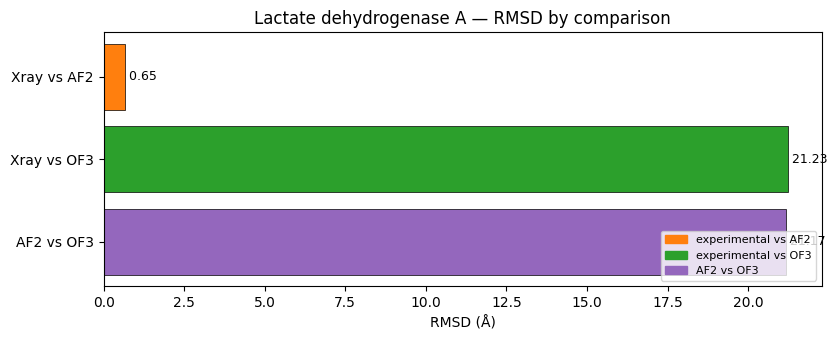

Saved: ../results/rmsd_Lysozyme_C_human.png


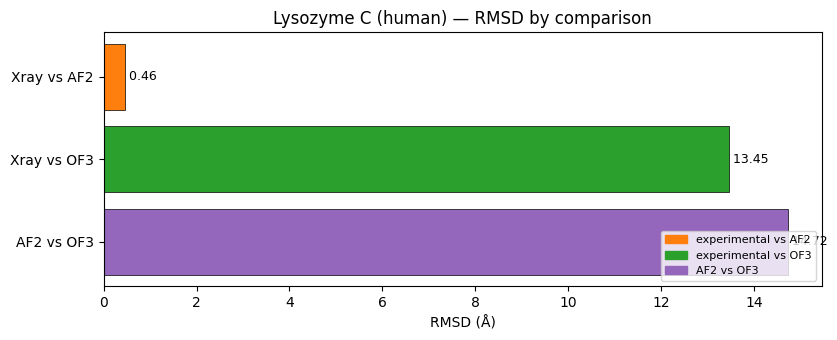

Saved: ../results/rmsd_Myoglobin.png


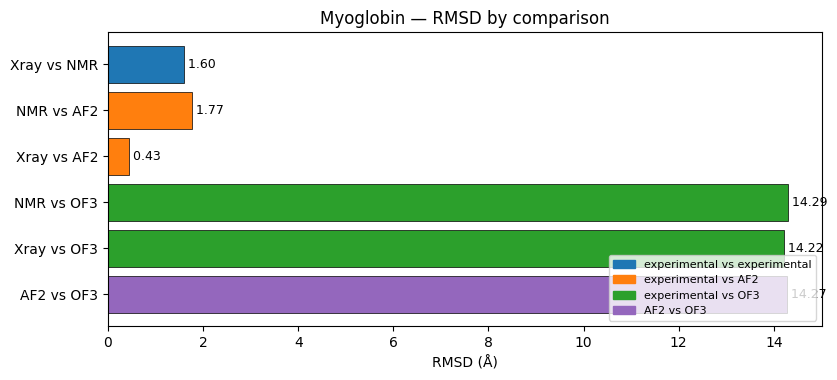

Saved: ../results/rmsd_Myosin-5a.png


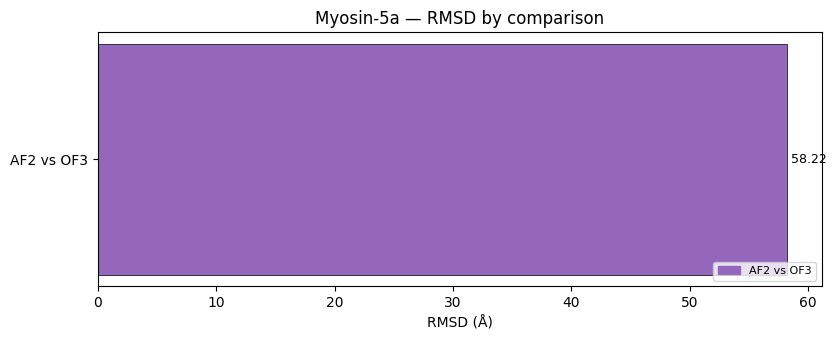

Saved: ../results/rmsd_Nucleoporin_Nup133.png


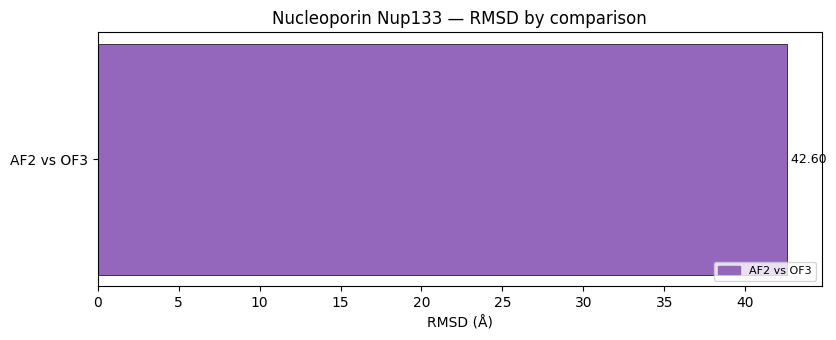

Saved: ../results/rmsd_P-glycoprotein_ABCB1.png


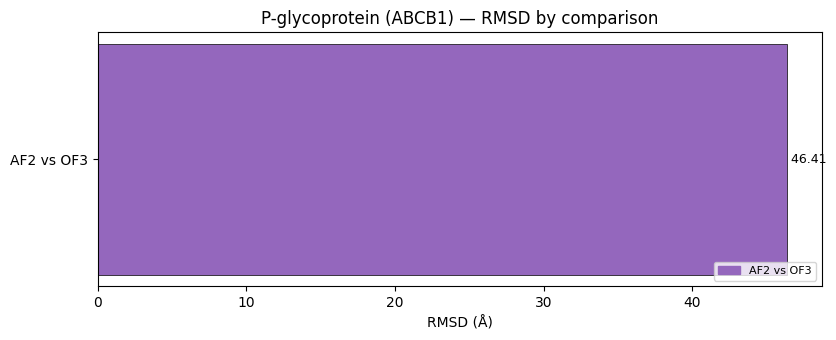

Saved: ../results/rmsd_Photosystem_II_protein_D1.png


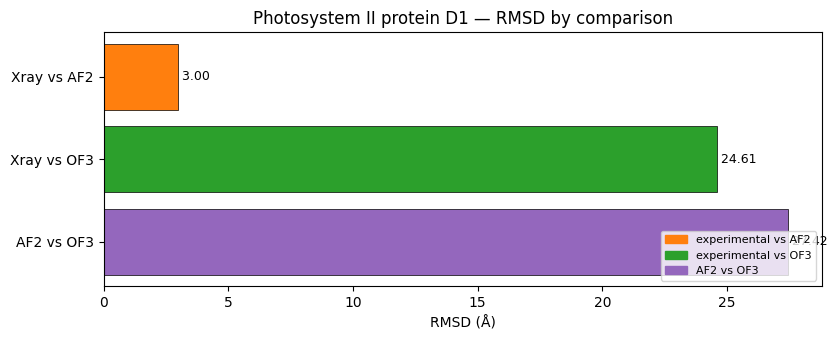

Saved: ../results/rmsd_Prion_protein_PrP.png


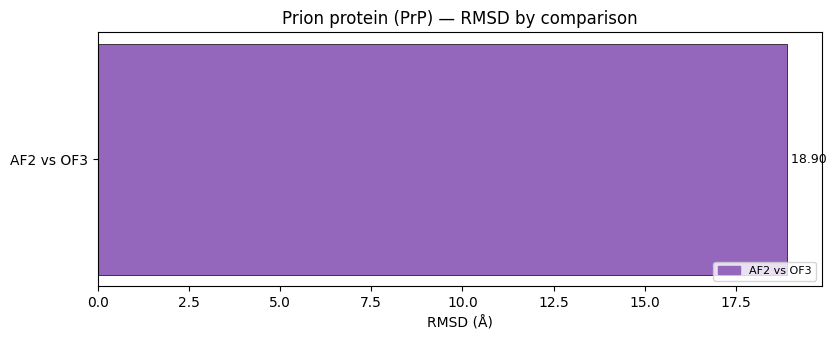

Saved: ../results/rmsd_Proteasome_subunit_Rpt1.png


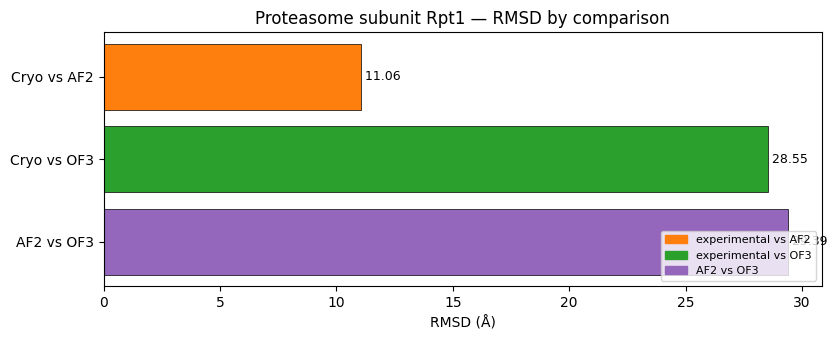

Saved: ../results/rmsd_Protein_G_GB1_domain_parent.png


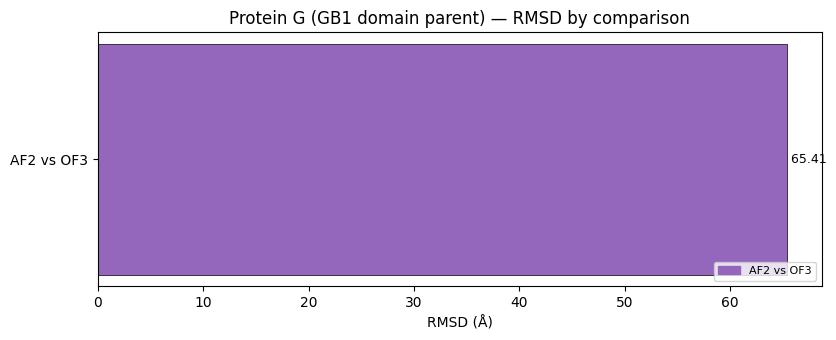

Saved: ../results/rmsd_RNA_polymerase_II_subunit_RPB1.png


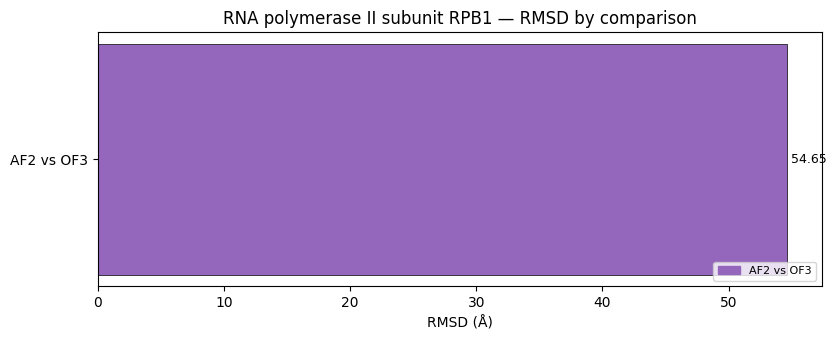

Saved: ../results/rmsd_Ribonuclease_A.png


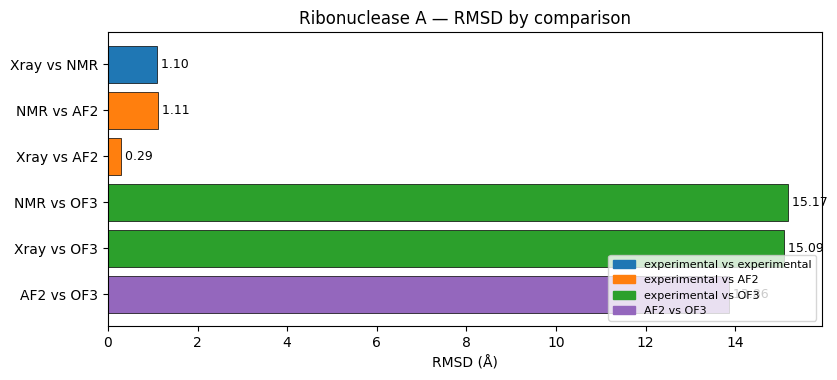

Saved: ../results/rmsd_Ribosomal_protein_L3_E_coli.png


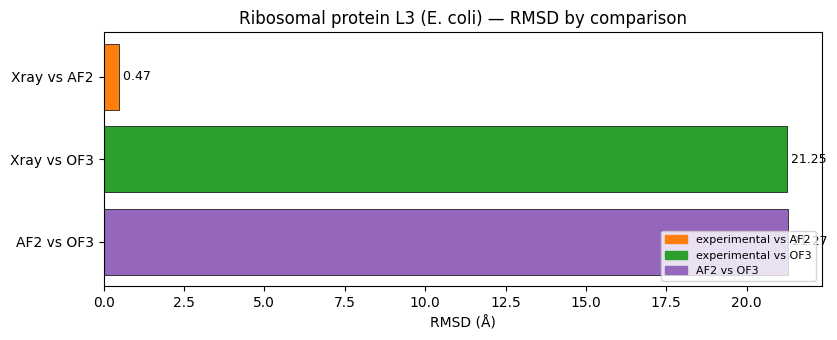

Saved: ../results/rmsd_Ribosomal_protein_S7.png


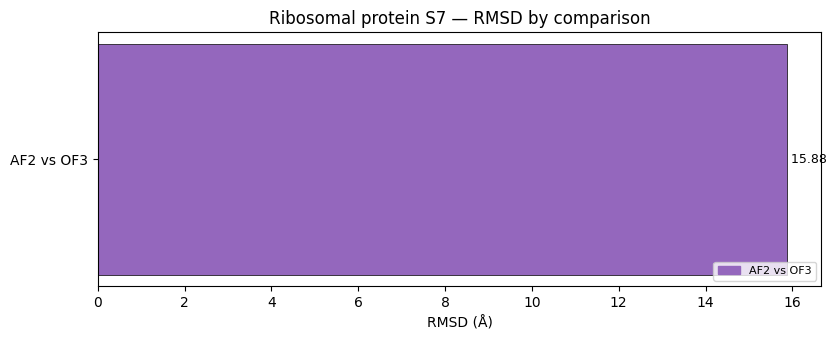

Saved: ../results/rmsd_SARS-CoV-2_spike_glycoprotein.png


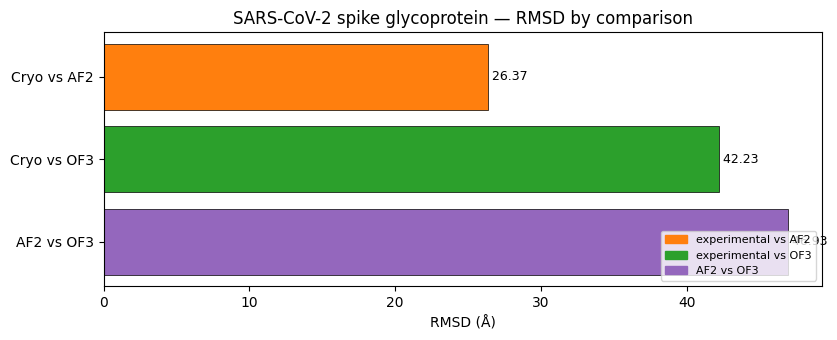

Saved: ../results/rmsd_Spectrin_alpha_chain.png


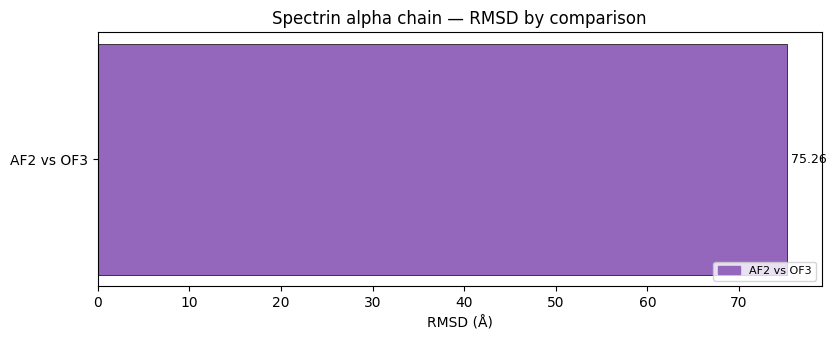

Saved: ../results/rmsd_Spliceosome_protein_SF3B1.png


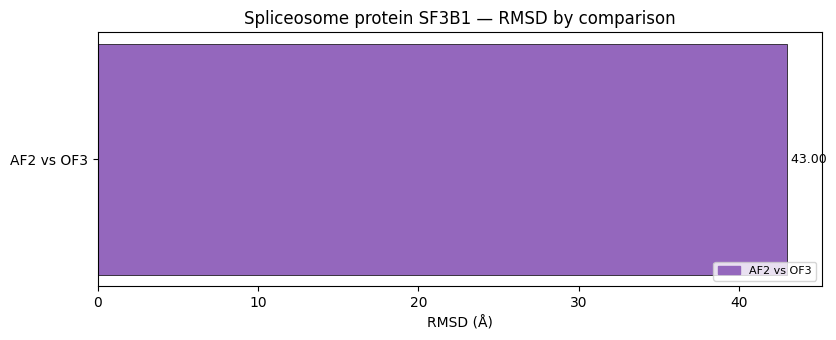

Saved: ../results/rmsd_Staphylococcal_nuclease.png


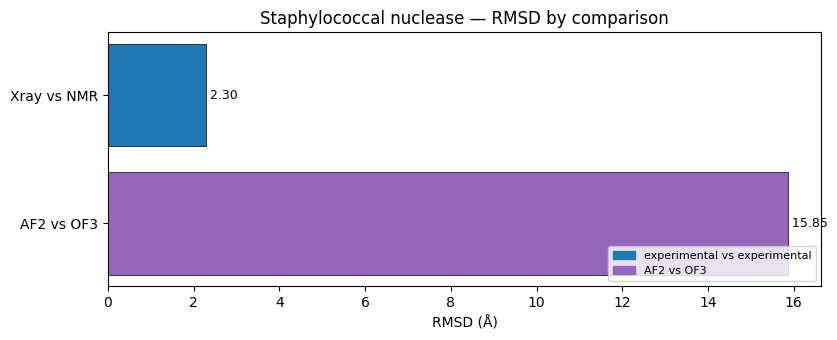

Saved: ../results/rmsd_Superoxide_dismutase_1_human.png


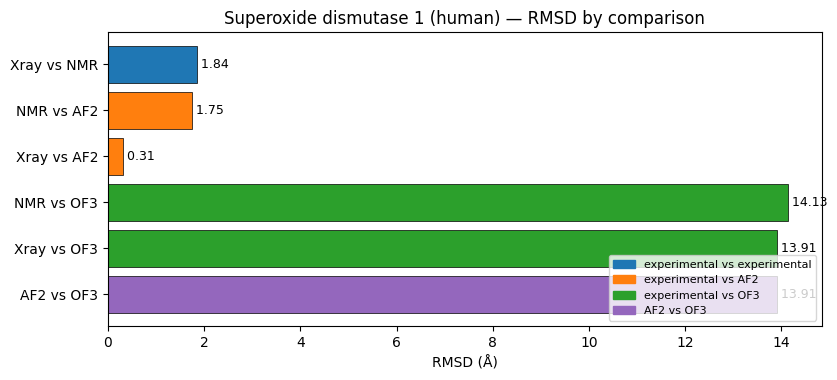

Saved: ../results/rmsd_T4_lysozyme.png


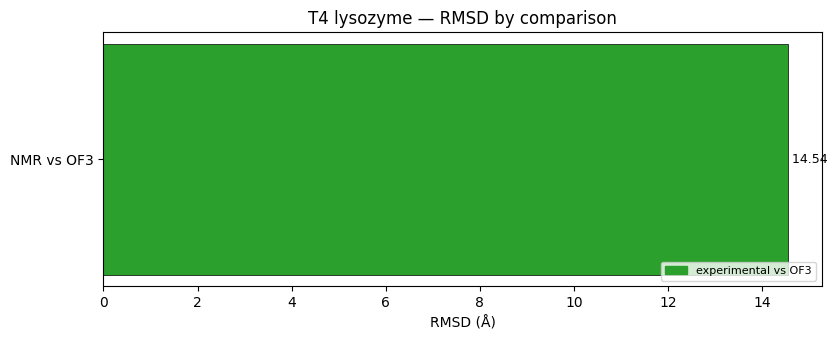

Saved: ../results/rmsd_TEM-1_beta-lactamase.png


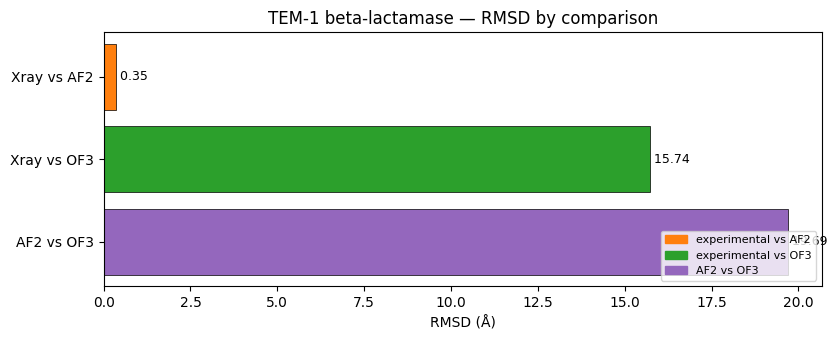

Saved: ../results/rmsd_TRPV1_ion_channel.png


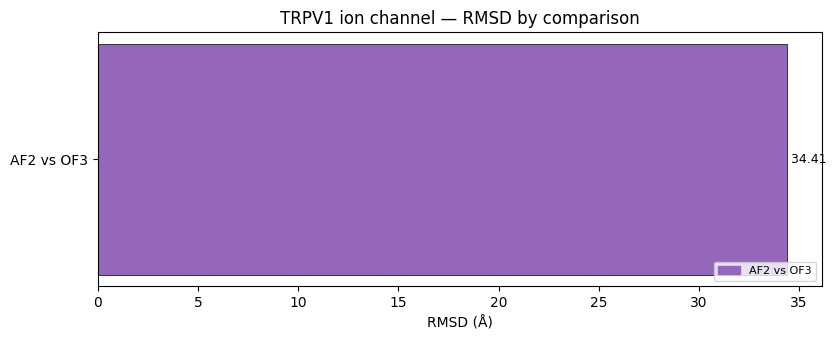

Saved: ../results/rmsd_Tau_protein.png


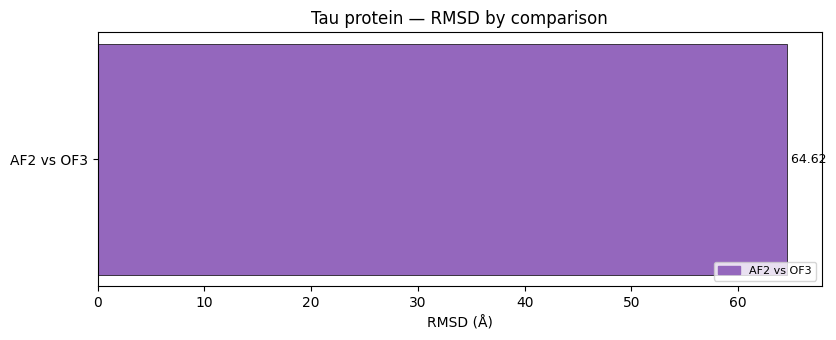

Saved: ../results/rmsd_Thioredoxin_E_coli.png


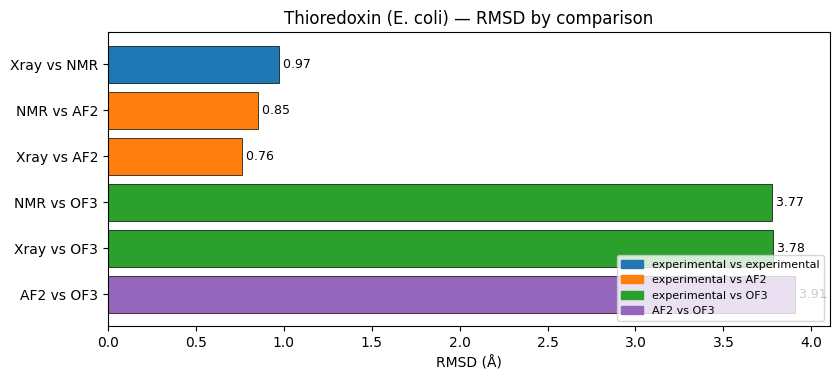

Saved: ../results/rmsd_Toll-like_receptor_4_TLR4.png


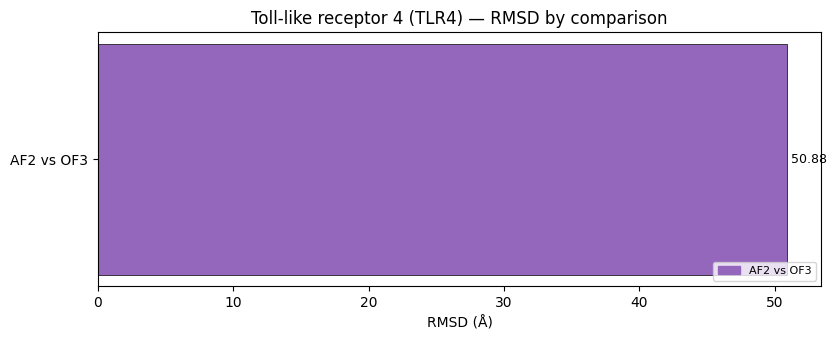

Saved: ../results/rmsd_Transthyretin.png


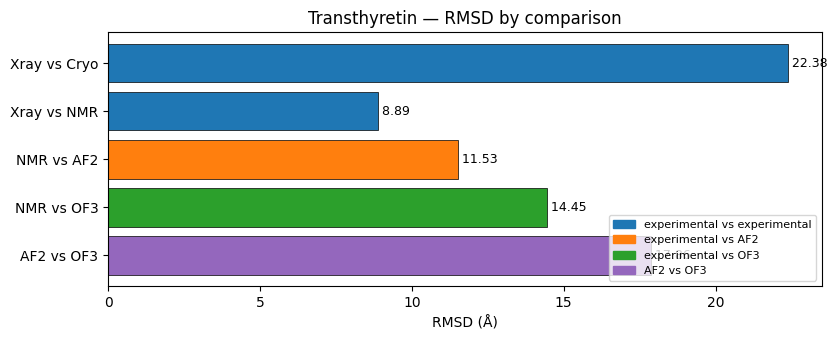

Saved: ../results/rmsd_Tubulin_beta_chain.png


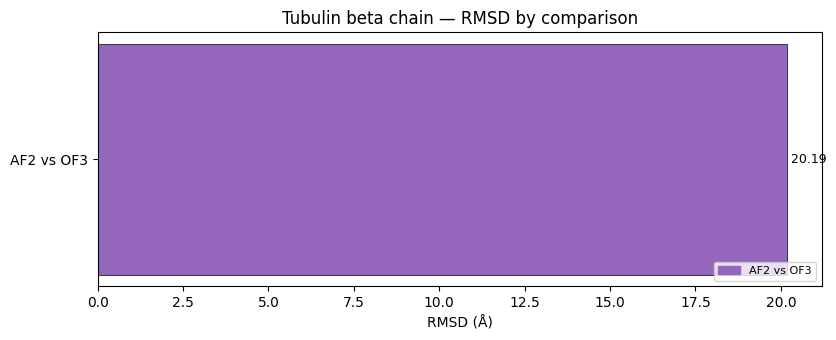

Saved: ../results/rmsd_Tumor_protein_p53.png


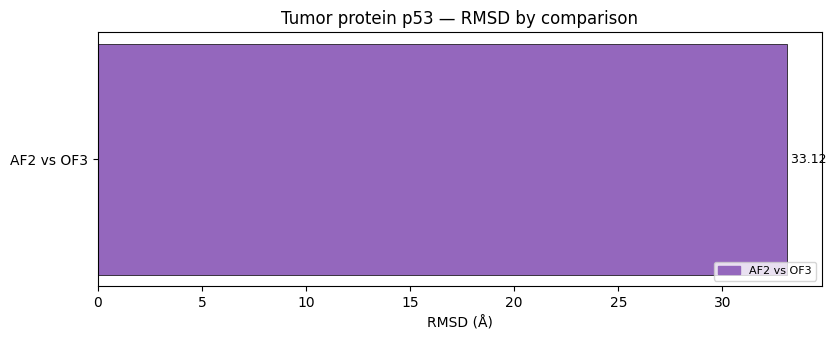

Saved: ../results/rmsd_V-ATPase_subunit_A.png


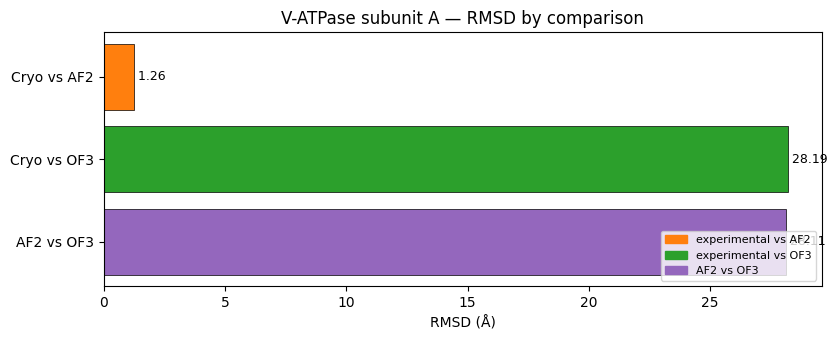

Saved: ../results/rmsd_Vimentin.png


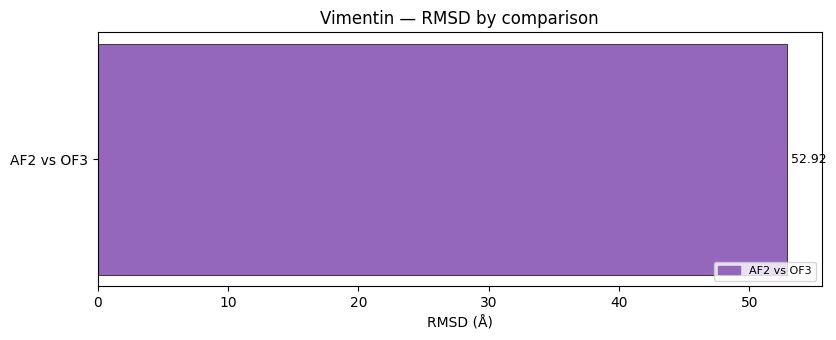

Saved: ../results/rmsd_c-Myc.png


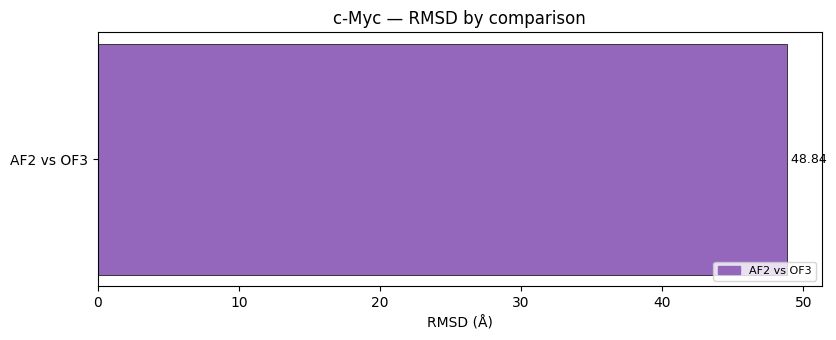

Saved: ../results/rmsd_p27_Kip1.png


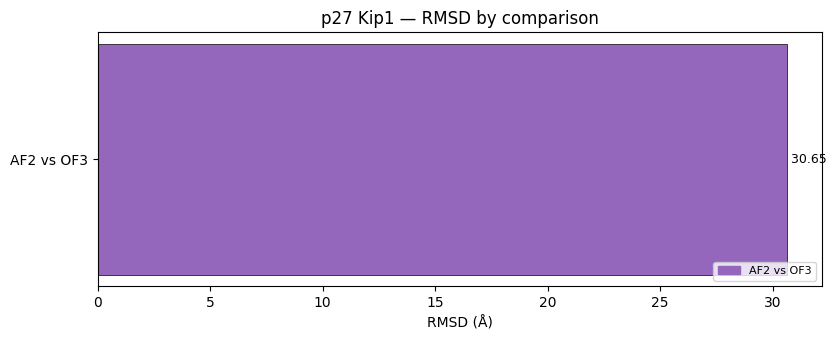

In [8]:
if "rmsd" in main_df.columns:
    for protein, p in main_df.dropna(subset=["rmsd"]).groupby(
        "protein_name", sort=True
    ):
        p = p.copy()
        p["short_label"] = p["comparison"].map(short_comparison_label)
        p["cat_order"] = (
            p.get("category", pd.Series(index=p.index, dtype=object))
            .map({"exp_vs_exp": 0, "exp_vs_af2": 1, "exp_vs_of3": 2, "af2_vs_of3": 3})
            .fillna(9)
        )
        p = p.sort_values(["cat_order", "comparison"])

        fig, ax = plt.subplots(figsize=(8.5, max(3.5, 0.45 * len(p) + 1.2)))
        colors = (
            p.get("category", pd.Series(index=p.index, dtype=object))
            .map(CATEGORY_COLORS)
            .fillna("tab:gray")
        )
        ax.barh(
            p["short_label"], p["rmsd"], color=colors, edgecolor="black", linewidth=0.5
        )
        ax.invert_yaxis()
        ax.set_title(f"{protein} — RMSD by comparison")
        ax.set_xlabel("RMSD (Å)")
        ax.set_ylabel("")

        for y, v in enumerate(p["rmsd"]):
            ax.text(float(v), y, f" {float(v):.2f}", va="center", fontsize=9)

        handles = []
        for cat in p.get("category", pd.Series(dtype=object)).dropna().unique():
            handles.append(
                mpatches.Patch(
                    color=CATEGORY_COLORS.get(cat, "tab:gray"),
                    label=CATEGORY_LABELS.get(cat, cat),
                )
            )
        if handles:
            ax.legend(handles=handles, fontsize=8, loc="lower right")

        plt.tight_layout()
        safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", str(protein)).strip("_")
        save_show(fig, f"rmsd_{safe_name}.png")

## Compact all-protein RMSD summary

This shows the same information as the per-protein plots, but as one readable table-like heatmap.

Saved: ../results/heatmap_rmsd_all.png


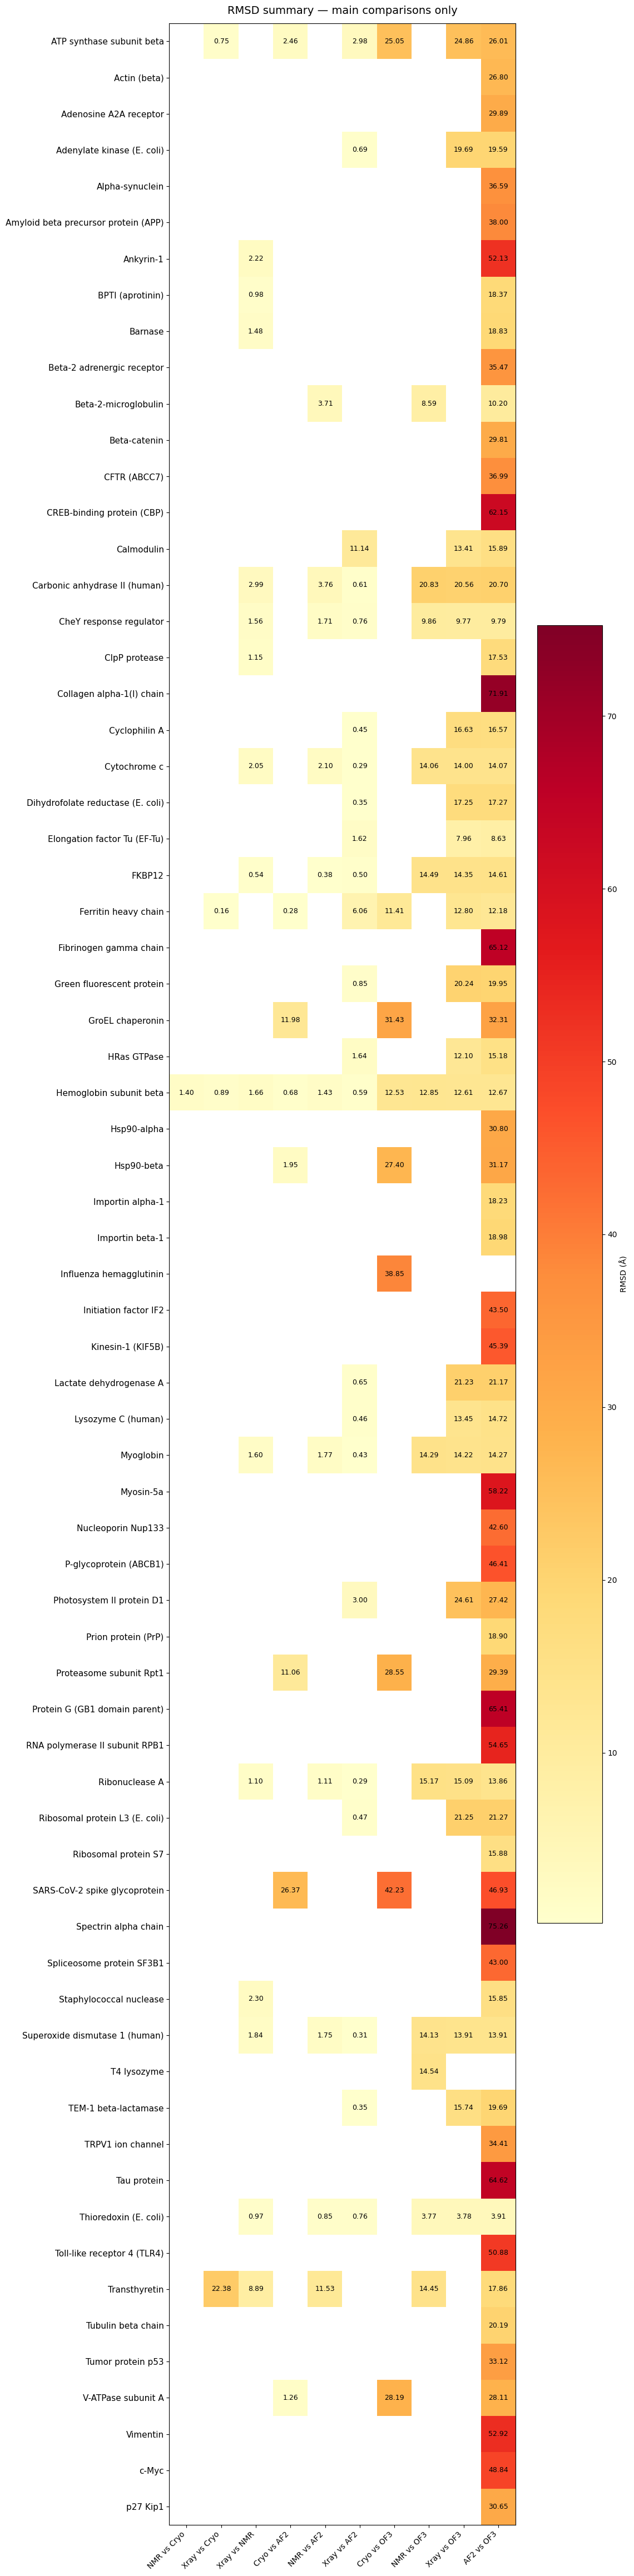

In [9]:
readable_heatmap(
    "rmsd",
    "RMSD summary — main comparisons only",
    cmap="YlOrRd",
    filename="heatmap_rmsd_all.png",
)

## NMR intra-ensemble plots

NMR model-to-model variability is a different biological quantity from AI-vs-experiment deviation, so it should not be mixed into the main heatmaps.

Saved: ../results/nmr_intra_rmsd_Ankyrin-1.png


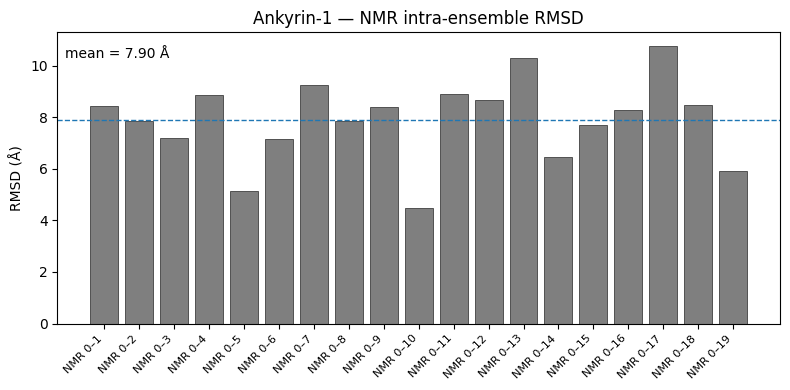

Saved: ../results/nmr_intra_rmsd_BPTI_aprotinin.png


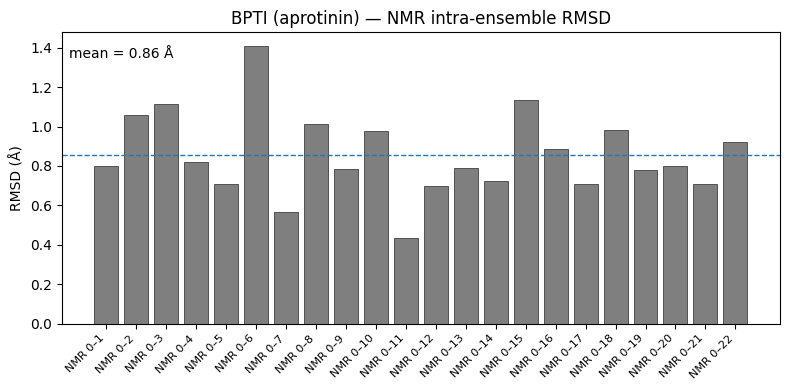

Saved: ../results/nmr_intra_rmsd_Barnase.png


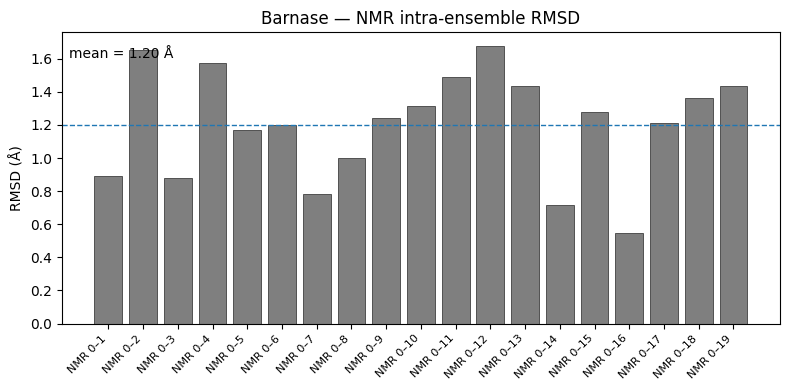

Saved: ../results/nmr_intra_rmsd_Beta-2_adrenergic_receptor.png


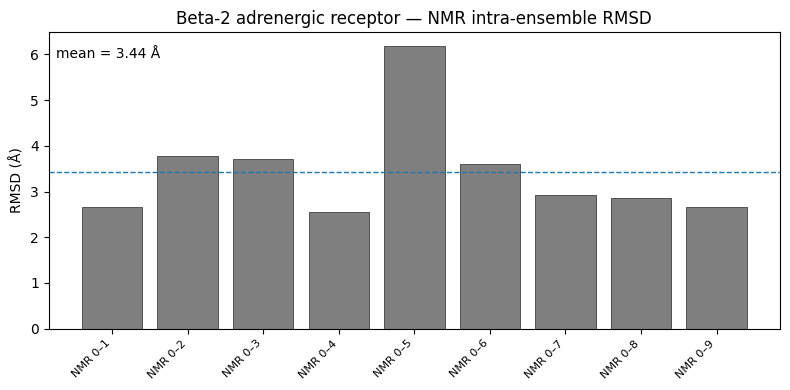

Saved: ../results/nmr_intra_rmsd_Beta-2-microglobulin.png


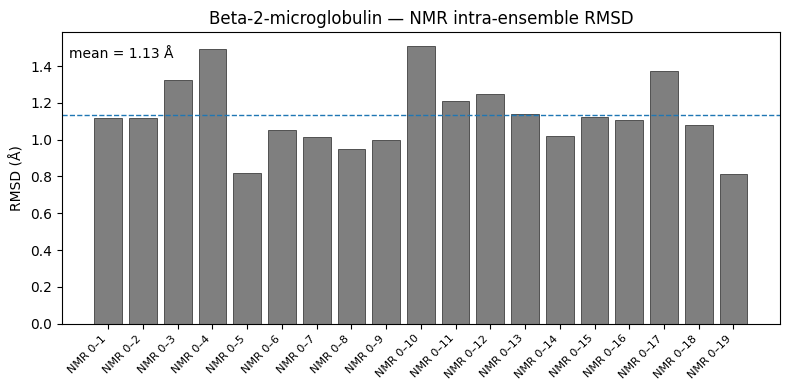

Saved: ../results/nmr_intra_rmsd_CFTR_ABCC7.png


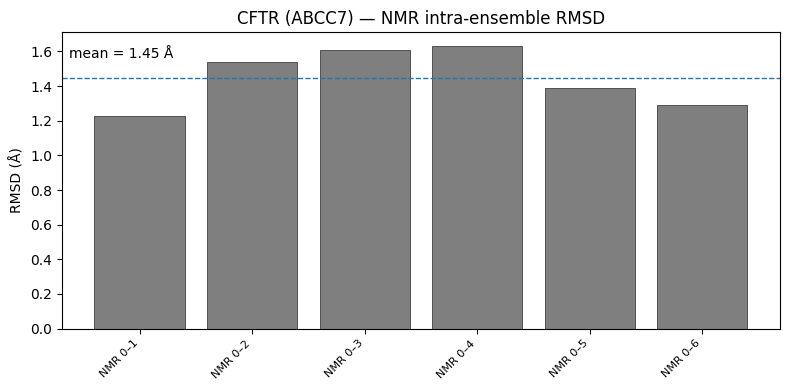

Saved: ../results/nmr_intra_rmsd_Calmodulin.png


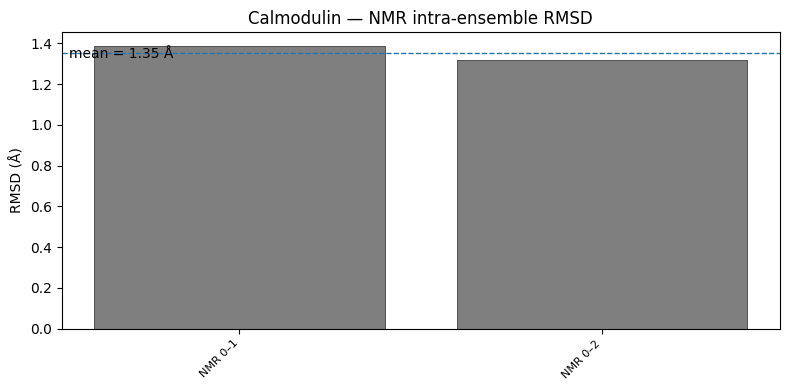

Saved: ../results/nmr_intra_rmsd_Carbonic_anhydrase_II_human.png


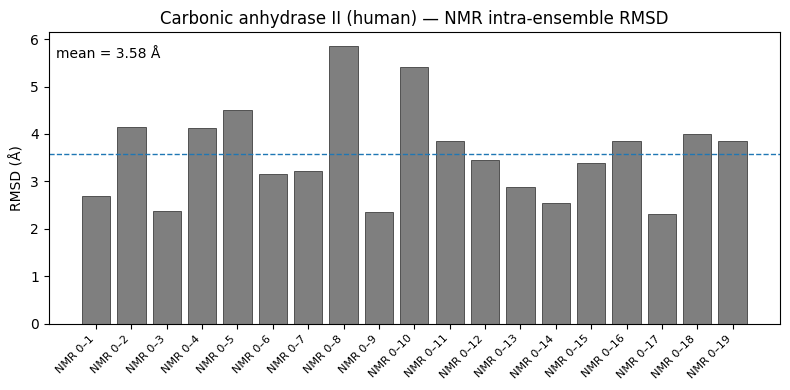

Saved: ../results/nmr_intra_rmsd_CheY_response_regulator.png


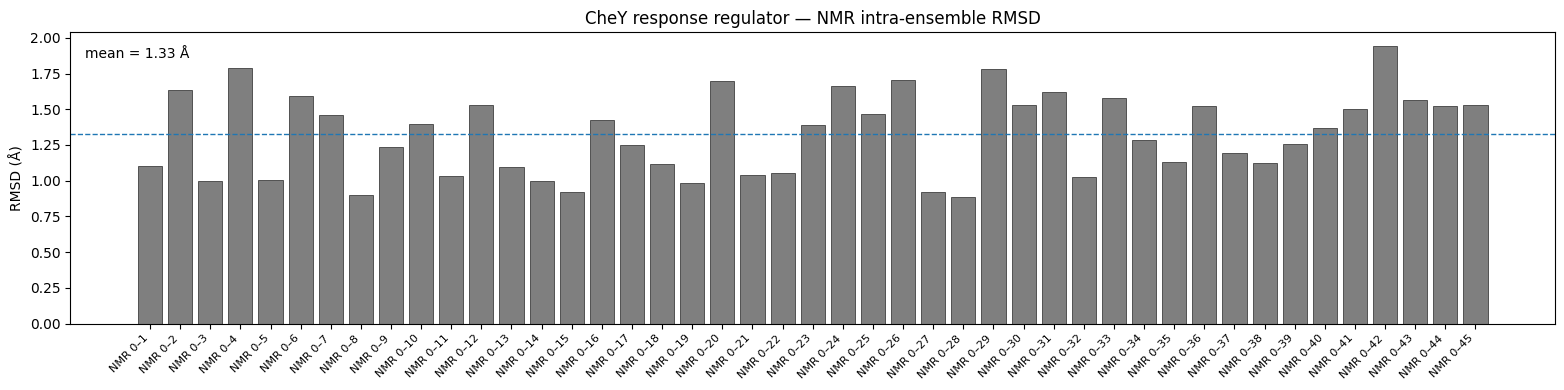

Saved: ../results/nmr_intra_rmsd_ClpP_protease.png


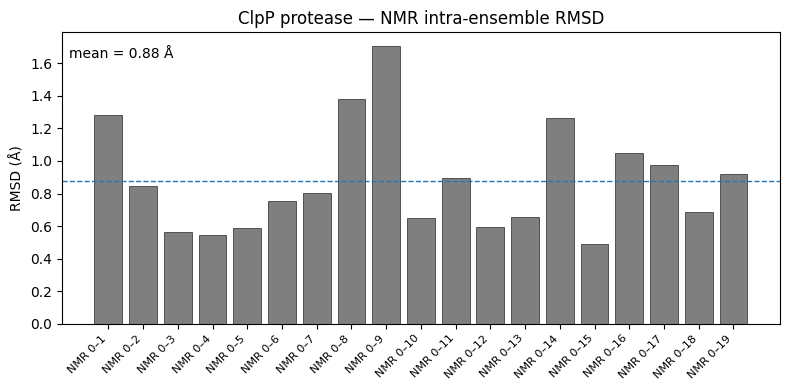

Saved: ../results/nmr_intra_rmsd_Cytochrome_c.png


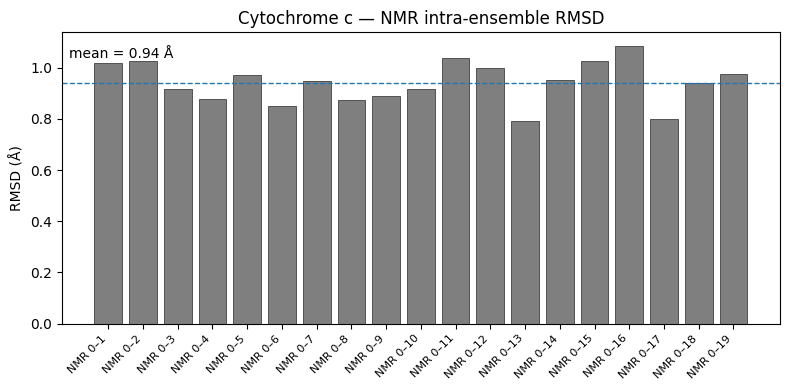

Saved: ../results/nmr_intra_rmsd_FKBP12.png


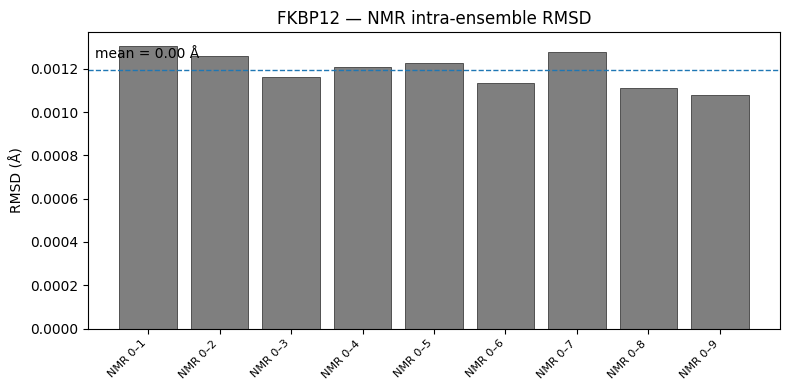

Saved: ../results/nmr_intra_rmsd_Hemoglobin_subunit_beta.png


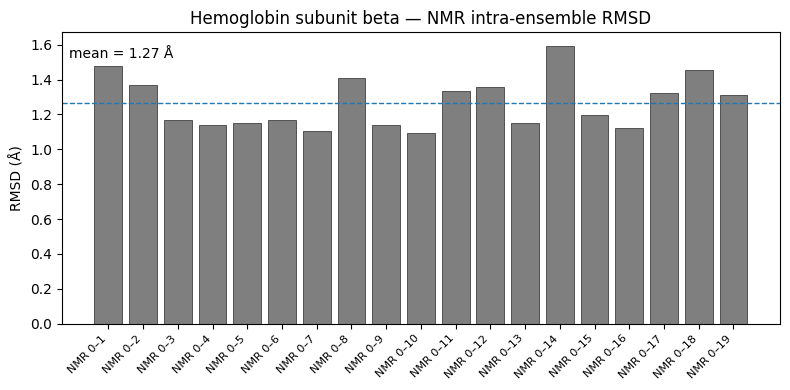

Saved: ../results/nmr_intra_rmsd_Hsp90-beta.png


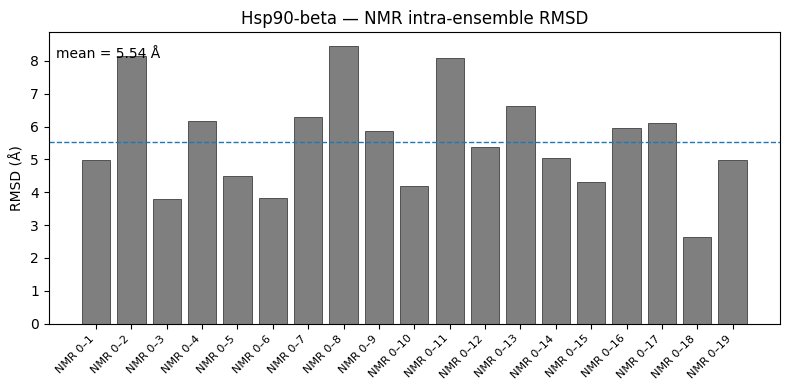

Saved: ../results/nmr_intra_rmsd_Initiation_factor_IF2.png


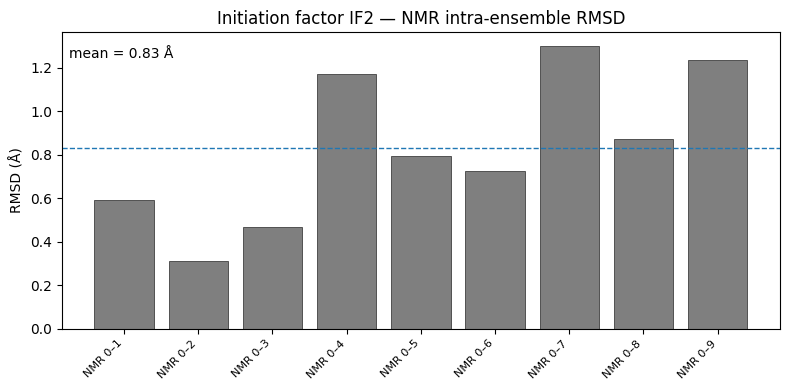

Saved: ../results/nmr_intra_rmsd_Myoglobin.png


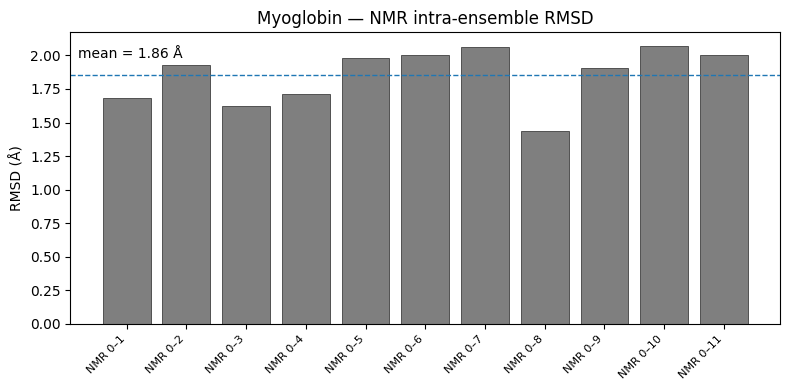

Saved: ../results/nmr_intra_rmsd_Prion_protein_PrP.png


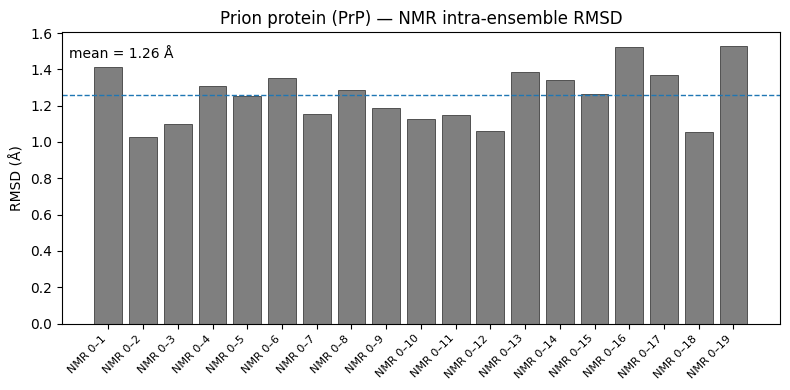

Saved: ../results/nmr_intra_rmsd_Protein_G_GB1_domain_parent.png


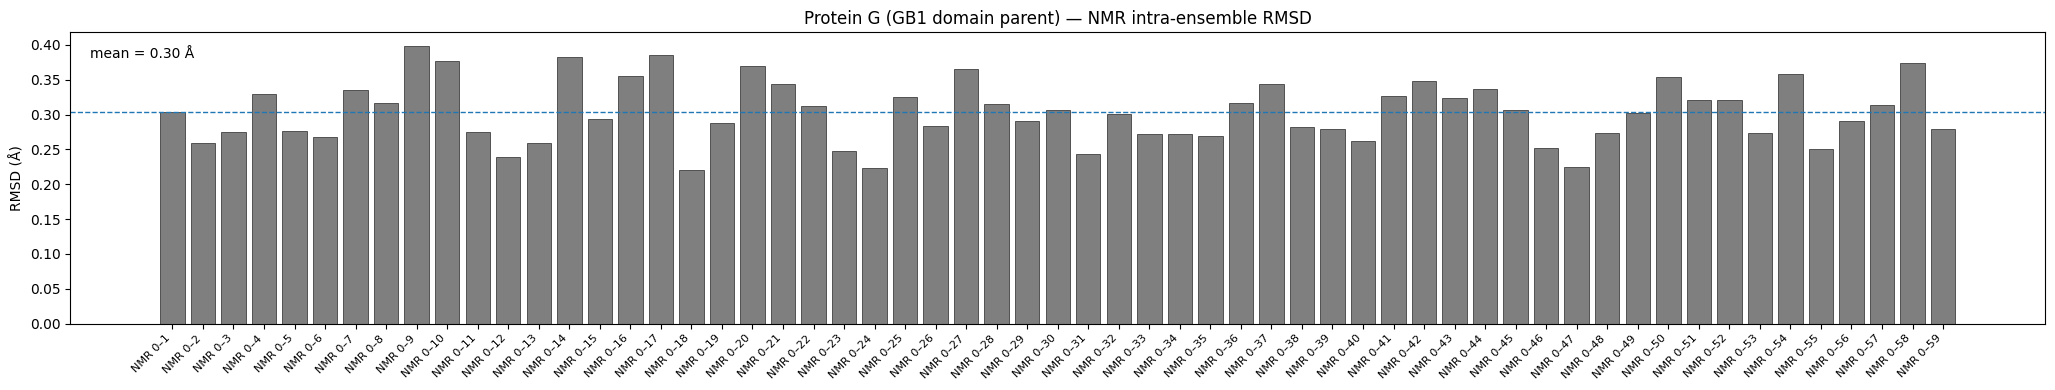

Saved: ../results/nmr_intra_rmsd_Ribonuclease_A.png


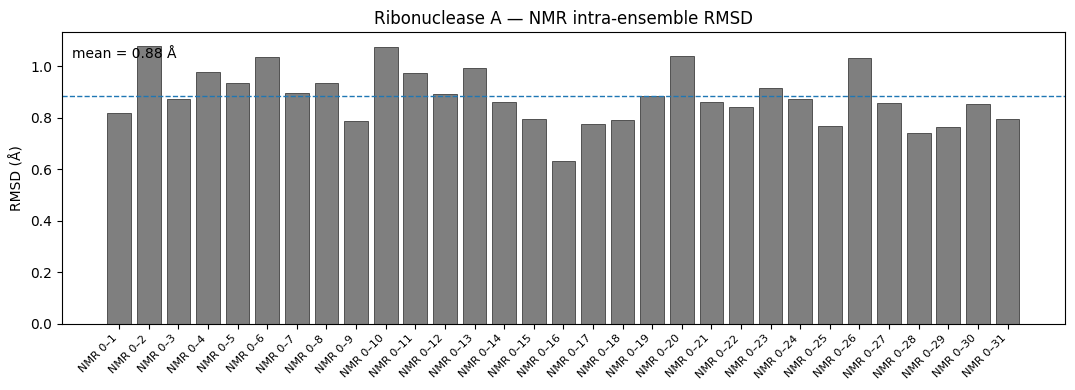

Saved: ../results/nmr_intra_rmsd_Spectrin_alpha_chain.png


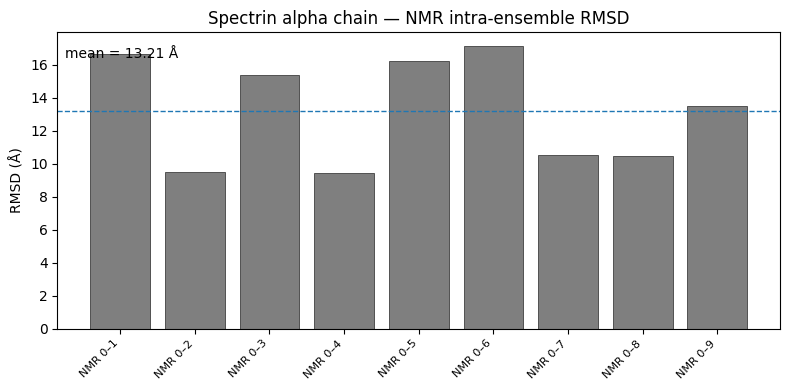

Saved: ../results/nmr_intra_rmsd_Superoxide_dismutase_1_human.png


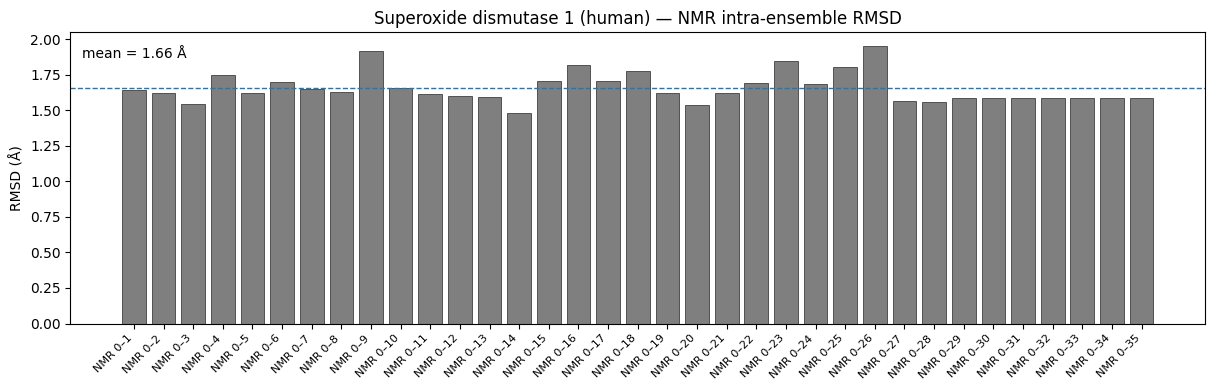

Saved: ../results/nmr_intra_rmsd_T4_lysozyme.png


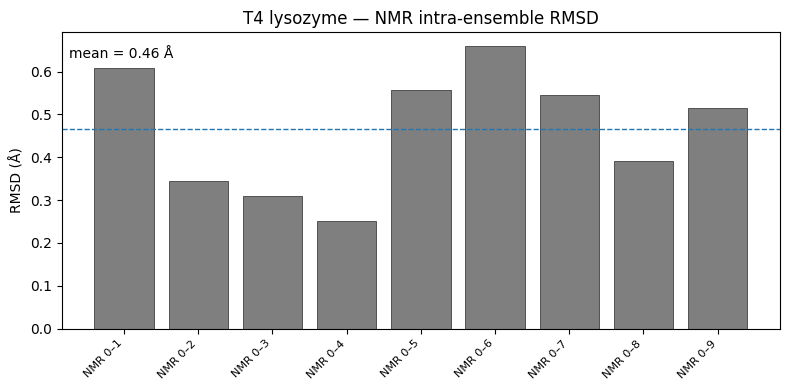

Saved: ../results/nmr_intra_rmsd_Thioredoxin_E_coli.png


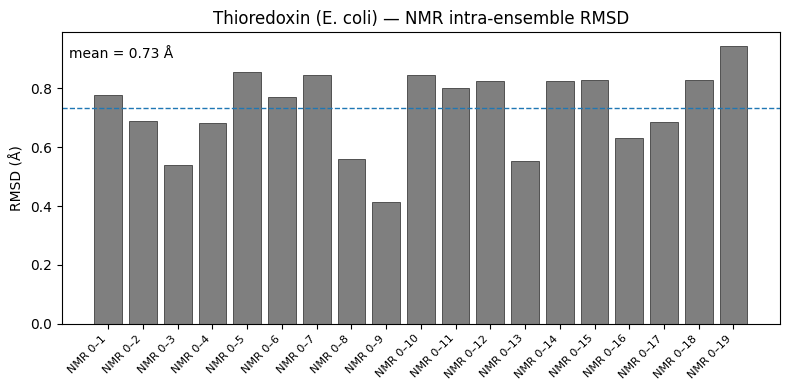

Saved: ../results/nmr_intra_rmsd_Toll-like_receptor_4_TLR4.png


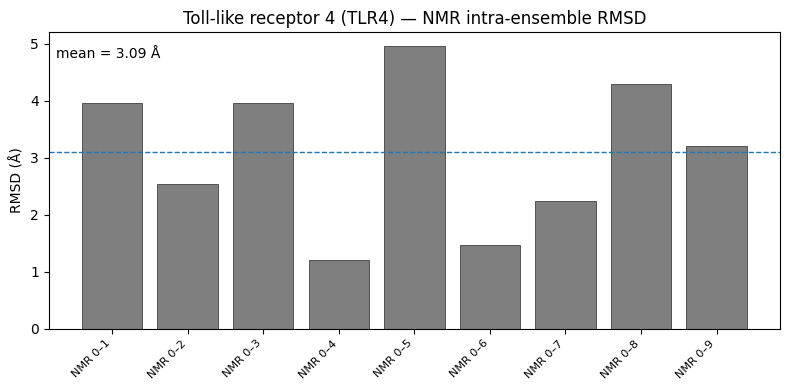

Saved: ../results/nmr_intra_rmsd_Transthyretin.png


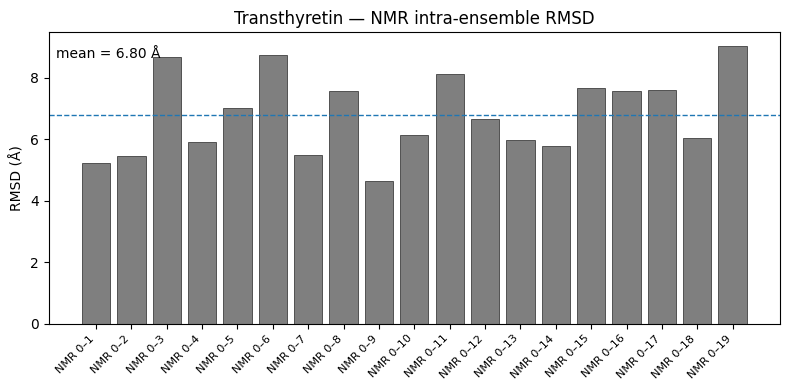

In [10]:
if nmr_df.empty:
    print("No NMR intra-ensemble rows found.")
else:
    nmr_df = nmr_df.copy()
    nmr_df["short_label"] = nmr_df["comparison"].map(short_comparison_label)
    nmr_df["model_b"] = (
        nmr_df["comparison"]
        .astype(str)
        .str.extract(r"model\d+.*model(\d+)", flags=re.IGNORECASE)
        .astype(float)
    )

    for protein, p in nmr_df.dropna(subset=["rmsd"]).groupby("protein_name", sort=True):
        p = p.sort_values(["model_b", "comparison"])

        fig, ax = plt.subplots(figsize=(max(8, 0.35 * len(p)), 4))
        x = np.arange(len(p))
        ax.bar(
            x,
            p["rmsd"],
            color=CATEGORY_COLORS["nmr_intra_ensemble"],
            edgecolor="black",
            linewidth=0.4,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(p["short_label"], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("RMSD (Å)")
        ax.set_title(f"{protein} — NMR intra-ensemble RMSD")

        if len(p) > 1:
            mean_val = float(p["rmsd"].mean())
            ax.axhline(mean_val, linestyle="--", linewidth=1)
            ax.text(
                0.01, 0.95, f"mean = {mean_val:.2f} Å", transform=ax.transAxes, va="top"
            )

        plt.tight_layout()
        safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", str(protein)).strip("_")
        save_show(fig, f"nmr_intra_rmsd_{safe_name}.png")

## Per-protein metric summary by comparison category

In [11]:
category_metric_cols = [
    c for c in ["rmsd", "b_phipsi", "t_alpha", "w_rdist_norm"] if c in main_df.columns
]

category_tables = {}
for col in category_metric_cols:
    grp = main_df.groupby(["protein_name", "category"])[col].mean().unstack()
    category_tables[col] = grp
    print(f"=== {col} mean per category ===")
    display(grp.round(4))

wide_parts = []
for metric, table in category_tables.items():
    tmp = table.copy()
    tmp.columns = [f"{metric}__{c}" for c in tmp.columns]
    wide_parts.append(tmp)

if wide_parts:
    report_summary = pd.concat(wide_parts, axis=1).reset_index()
    report_summary.to_csv(RESULTS_DIR / "category_means_readable.csv", index=False)
    display(report_summary.round(4))

=== rmsd mean per category ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3
protein_name,,,,
ATP synthase subunit beta,26.0096,2.7203,0.7507,24.9593
Actin (beta),26.7952,NaN,NaN,NaN
Adenosine A2A receptor,29.8853,NaN,NaN,NaN
Adenylate kinase (E. coli),19.5858,0.6855,NaN,19.6927
Alpha-synuclein,36.5854,NaN,NaN,NaN
...,...,...,...,...
Tumor protein p53,33.1168,NaN,NaN,NaN
V-ATPase subunit A,28.1129,1.2620,NaN,28.1899
Vimentin,52.9161,NaN,NaN,NaN


=== b_phipsi mean per category ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3
protein_name,,,,
ATP synthase subunit beta,0.0442,0.0041,0.0017,0.0203
Actin (beta),0.0071,NaN,NaN,NaN
Adenosine A2A receptor,0.0551,NaN,NaN,NaN
Adenylate kinase (E. coli),0.0052,0.0027,NaN,0.0125
Alpha-synuclein,0.1483,NaN,NaN,NaN
...,...,...,...,...
Tumor protein p53,0.0331,NaN,NaN,NaN
V-ATPase subunit A,0.0127,0.0088,NaN,0.0271
Vimentin,0.0336,NaN,NaN,NaN


=== t_alpha mean per category ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3
protein_name,,,,
ATP synthase subunit beta,0.2551,0.0968,0.0564,0.0817
Actin (beta),0.1636,NaN,NaN,NaN
Adenosine A2A receptor,0.0420,NaN,NaN,NaN
Adenylate kinase (E. coli),0.1687,0.1632,NaN,0.0048
Alpha-synuclein,0.1366,NaN,NaN,NaN
...,...,...,...,...
Tumor protein p53,0.0931,NaN,NaN,NaN
V-ATPase subunit A,0.0344,0.0379,NaN,0.0043
Vimentin,0.1489,NaN,NaN,NaN


=== w_rdist_norm mean per category ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3
protein_name,,,,
ATP synthase subunit beta,0.6461,0.0428,0.0378,0.4725
Actin (beta),0.8824,NaN,NaN,NaN
Adenosine A2A receptor,0.8176,NaN,NaN,NaN
Adenylate kinase (E. coli),0.6866,0.0240,NaN,0.6905
Alpha-synuclein,1.4338,NaN,NaN,NaN
...,...,...,...,...
Tumor protein p53,0.9760,NaN,NaN,NaN
V-ATPase subunit A,0.5283,0.2652,NaN,0.5374
Vimentin,1.3259,NaN,NaN,NaN


,protein_name,rmsd__af2_vs_of3,rmsd__exp_vs_af2,rmsd__exp_vs_exp,rmsd__exp_vs_of3,b_phipsi__af2_vs_of3,b_phipsi__exp_vs_af2,b_phipsi__exp_vs_exp,b_phipsi__exp_vs_of3,t_alpha__af2_vs_of3,t_alpha__exp_vs_af2,t_alpha__exp_vs_exp,t_alpha__exp_vs_of3,w_rdist_norm__af2_vs_of3,w_rdist_norm__exp_vs_af2,w_rdist_norm__exp_vs_exp,w_rdist_norm__exp_vs_of3
0,ATP synthase subunit beta,26.0096,2.7203,0.7507,24.9593,0.0442,0.0041,0.0017,0.0203,0.2551,0.0968,0.0564,0.0817,0.6461,0.0428,0.0378,0.4725
1,Actin (beta),26.7952,NaN,NaN,NaN,0.0071,NaN,NaN,NaN,0.1636,NaN,NaN,NaN,0.8824,NaN,NaN,NaN
2,Adenosine A2A receptor,29.8853,NaN,NaN,NaN,0.0551,NaN,NaN,NaN,0.0420,NaN,NaN,NaN,0.8176,NaN,NaN,NaN
3,Adenylate kinase (E. coli),19.5858,0.6855,NaN,19.6927,0.0052,0.0027,NaN,0.0125,0.1687,0.1632,NaN,0.0048,0.6866,0.0240,NaN,0.6905
4,Alpha-synuclein,36.5854,NaN,NaN,NaN,0.1483,NaN,NaN,NaN,0.1366,NaN,NaN,NaN,1.4338,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,Tumor protein p53,33.1168,NaN,NaN,NaN,0.0331,NaN,NaN,NaN,0.0931,NaN,NaN,NaN,0.9760,NaN,NaN,NaN
65,V-ATPase subunit A,28.1129,1.2620,NaN,28.1899,0.0127,0.0088,NaN,0.0271,0.0344,0.0379,NaN,0.0043,0.5283,0.2652,NaN,0.5374
66,Vimentin,52.9161,NaN,NaN,NaN,0.0336,NaN,NaN,NaN,0.1489,NaN,NaN,NaN,1.3259,NaN,NaN,NaN
67,c-Myc,48.8424,NaN,NaN,NaN,0.0414,NaN,NaN,NaN,0.2412,NaN,NaN,NaN,1.3396,NaN,NaN,NaN


## Quick interpretation aid

Use this table to decide whether AF deviations are smaller/larger than the experimental baseline for each protein. This is descriptive only, not a hypothesis test.

In [12]:
for metric in ["rmsd", "b_phipsi", "t_alpha", "w_rdist_norm"]:
    if metric not in main_df.columns or "category" not in main_df.columns:
        continue

    metric_means = (
        main_df.groupby(["protein_name", "category"])[metric].mean().unstack()
    )
    interpretation = metric_means.copy()

    for cat in ["exp_vs_af2", "exp_vs_of3"]:
        if cat in interpretation.columns and "exp_vs_exp" in interpretation.columns:
            interpretation[f"{cat}_minus_exp_baseline"] = (
                interpretation[cat] - interpretation["exp_vs_exp"]
            )
            interpretation[f"{cat}_within_or_below_exp"] = (
                interpretation[cat] <= interpretation["exp_vs_exp"]
            )

    interpretation.to_csv(RESULTS_DIR / f"{metric}_interpretation_readable.csv")
    print(f"=== {metric_label(metric)} ===")
    display(interpretation.round(4))

=== RMSD (Å) ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3,exp_vs_af2_minus_exp_baseline,exp_vs_af2_within_or_below_exp,exp_vs_of3_minus_exp_baseline,exp_vs_of3_within_or_below_exp
protein_name,,,,,,,,
ATP synthase subunit beta,26.0096,2.7203,0.7507,24.9593,1.9696,False,24.2086,False
Actin (beta),26.7952,NaN,NaN,NaN,NaN,False,NaN,False
Adenosine A2A receptor,29.8853,NaN,NaN,NaN,NaN,False,NaN,False
Adenylate kinase (E. coli),19.5858,0.6855,NaN,19.6927,NaN,False,NaN,False
Alpha-synuclein,36.5854,NaN,NaN,NaN,NaN,False,NaN,False
...,...,...,...,...,...,...,...,...
Tumor protein p53,33.1168,NaN,NaN,NaN,NaN,False,NaN,False
V-ATPase subunit A,28.1129,1.2620,NaN,28.1899,NaN,False,NaN,False
Vimentin,52.9161,NaN,NaN,NaN,NaN,False,NaN,False


=== b-phi/psi (Bhattacharyya distance) ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3,exp_vs_af2_minus_exp_baseline,exp_vs_af2_within_or_below_exp,exp_vs_of3_minus_exp_baseline,exp_vs_of3_within_or_below_exp
protein_name,,,,,,,,
ATP synthase subunit beta,0.0442,0.0041,0.0017,0.0203,0.0024,False,0.0186,False
Actin (beta),0.0071,NaN,NaN,NaN,NaN,False,NaN,False
Adenosine A2A receptor,0.0551,NaN,NaN,NaN,NaN,False,NaN,False
Adenylate kinase (E. coli),0.0052,0.0027,NaN,0.0125,NaN,False,NaN,False
Alpha-synuclein,0.1483,NaN,NaN,NaN,NaN,False,NaN,False
...,...,...,...,...,...,...,...,...
Tumor protein p53,0.0331,NaN,NaN,NaN,NaN,False,NaN,False
V-ATPase subunit A,0.0127,0.0088,NaN,0.0271,NaN,False,NaN,False
Vimentin,0.0336,NaN,NaN,NaN,NaN,False,NaN,False


=== t-alpha (Å) ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3,exp_vs_af2_minus_exp_baseline,exp_vs_af2_within_or_below_exp,exp_vs_of3_minus_exp_baseline,exp_vs_of3_within_or_below_exp
protein_name,,,,,,,,
ATP synthase subunit beta,0.2551,0.0968,0.0564,0.0817,0.0404,False,0.0253,False
Actin (beta),0.1636,NaN,NaN,NaN,NaN,False,NaN,False
Adenosine A2A receptor,0.0420,NaN,NaN,NaN,NaN,False,NaN,False
Adenylate kinase (E. coli),0.1687,0.1632,NaN,0.0048,NaN,False,NaN,False
Alpha-synuclein,0.1366,NaN,NaN,NaN,NaN,False,NaN,False
...,...,...,...,...,...,...,...,...
Tumor protein p53,0.0931,NaN,NaN,NaN,NaN,False,NaN,False
V-ATPase subunit A,0.0344,0.0379,NaN,0.0043,NaN,False,NaN,False
Vimentin,0.1489,NaN,NaN,NaN,NaN,False,NaN,False


=== w-rdist normalised (dimensionless) ===


category,af2_vs_of3,exp_vs_af2,exp_vs_exp,exp_vs_of3,exp_vs_af2_minus_exp_baseline,exp_vs_af2_within_or_below_exp,exp_vs_of3_minus_exp_baseline,exp_vs_of3_within_or_below_exp
protein_name,,,,,,,,
ATP synthase subunit beta,0.6461,0.0428,0.0378,0.4725,0.0049,False,0.4346,False
Actin (beta),0.8824,NaN,NaN,NaN,NaN,False,NaN,False
Adenosine A2A receptor,0.8176,NaN,NaN,NaN,NaN,False,NaN,False
Adenylate kinase (E. coli),0.6866,0.0240,NaN,0.6905,NaN,False,NaN,False
Alpha-synuclein,1.4338,NaN,NaN,NaN,NaN,False,NaN,False
...,...,...,...,...,...,...,...,...
Tumor protein p53,0.9760,NaN,NaN,NaN,NaN,False,NaN,False
V-ATPase subunit A,0.5283,0.2652,NaN,0.5374,NaN,False,NaN,False
Vimentin,1.3259,NaN,NaN,NaN,NaN,False,NaN,False
